# ML Mega Completo — UNIGRAN Social — Kaggle Base Completa Profunda V2

Notebook ajustado para rodar no Kaggle com base completa, mantendo controle de RAM.

Mudança principal: os clusters não são mais um único KMeans genérico. O pipeline agora usa:

1. classificação por macroárea profissional;
2. subclusters dentro de cada macroárea;
3. recomendação por similaridade direta varrendo a base em chunks;
4. métricas e gráficos usando o novo formato.


# Ajustes profundos aplicados

Esta versão foi feita para resolver o problema de cluster fraco, onde quase tudo caía em um grupo genérico.

A estratégia agora é híbrida:

- **camada 1 — área profissional:** Data, Software, DevOps, Marketing, Design, Educação etc.;
- **camada 2 — subcluster:** grupos menores dentro de cada área;
- **camada 3 — recomendação:** similaridade direta entre postagem e vagas reais;
- **camada 4 — validação:** diagnóstico da distribuição dos clusters na base completa.

Para não quebrar a RAM, a base completa é varrida em chunks e a matriz vetorial completa nunca é salva na memória.


# 1. Instalação de dependências

No Kaggle, normalmente `pandas`, `numpy`, `scikit-learn`, `matplotlib` e `joblib` já vêm instalados.

Execute esta célula só se faltar alguma dependência.

In [1]:
# No Kaggle, rode somente se necessário.
# !pip install -q kagglehub scikit-learn pandas numpy matplotlib joblib fastapi uvicorn pydantic

# 2. Imports e configurações globais

In [2]:
import os
import re
import json
import math
import gc
import joblib
import warnings
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp

try:
    import kagglehub
except Exception:
    kagglehub = None

from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 200)

RANDOM_STATE = 42
DATASET_KAGGLE = "asaniczka/1-3m-linkedin-jobs-and-skills-2024"

# ==============================
# CONFIGURAÇÃO KAGGLE INTEGRAL PROFUNDA
# ==============================
RODAR_BASE_COMPLETA = True
AMOSTRA_FRAC = 1.0
AMOSTRA_MAXIMA = None
LIMITE_LEITURA_CSV = None

# Vetorização anti-RAM.
# 2**16 é mais seguro que 2**17 para varrer a base inteira em chunks no Kaggle gratuito.
HASHING_N_FEATURES = 2**16
HASHING_ALTERNATE_SIGN = False
HASHING_NGRAM_RANGE = (1, 2)

# Chunk menor = menos RAM. Se sobrar RAM no Kaggle, pode subir para 20000 ou 25000.
CHUNK_VETORIZACAO = 10000

# Clusterização profunda: subclusters dentro de cada área.
KMEANS_BATCH_SIZE = 4096
KMEANS_N_INIT = 5
SUBCLUSTERS_MIN_REGISTROS = 300
SUBCLUSTERS_MAX_POR_AREA = 5

# Avaliação pesada continua por amostra, mas a distribuição/contagem é na base toda.
AMOSTRA_AVALIACAO_CLUSTER = 4000
AMOSTRA_PLOT_2D = 4000

# Recomendação: varre a base inteira em chunks.
# Isso é mais lento, mas muito mais correto para o TCC do que usar só um pool pequeno.
RECOMENDACAO_BASE_COMPLETA = True
TOP_N_RECOMENDACOES = 10
TOP_N_CANDIDATOS_CHUNK = 80

PASTA_MODELOS = Path("models")
PASTA_SAIDAS = Path("outputs")
PASTA_MODELOS.mkdir(exist_ok=True)
PASTA_SAIDAS.mkdir(exist_ok=True)

print("Configuração ativa: KAGGLE BASE COMPLETA PROFUNDA")
print("RODAR_BASE_COMPLETA:", RODAR_BASE_COMPLETA)
print("LIMITE_LEITURA_CSV:", LIMITE_LEITURA_CSV)
print("HASHING_N_FEATURES:", HASHING_N_FEATURES)
print("CHUNK_VETORIZACAO:", CHUNK_VETORIZACAO)
print("RECOMENDACAO_BASE_COMPLETA:", RECOMENDACAO_BASE_COMPLETA)

Configuração ativa: KAGGLE BASE COMPLETA PROFUNDA
RODAR_BASE_COMPLETA: True
LIMITE_LEITURA_CSV: None
HASHING_N_FEATURES: 65536
CHUNK_VETORIZACAO: 10000
RECOMENDACAO_BASE_COMPLETA: True


# 3. Carregamento dos dados do Kaggle

A base usada como referência de mercado contém vagas, cargos, descrições e habilidades.

O notebook tenta carregar os arquivos mais comuns:

- `linkedin_job_postings.csv`
- `job_skills.csv`
- `job_summary.csv`

Caso algum nome venha diferente, o código tenta listar os arquivos baixados.

In [3]:
def listar_arquivos_dataset(dataset_name=DATASET_KAGGLE):
    """Localiza o dataset no Kaggle.

    Prioridade:
    1. /kaggle/input, quando o dataset foi anexado pelo botão Add Data;
    2. kagglehub.dataset_download(), quando disponível.
    """
    caminhos_possiveis = []

    base_kaggle = Path('/kaggle/input')
    if base_kaggle.exists():
        for pasta in base_kaggle.iterdir():
            if pasta.is_dir():
                caminhos_possiveis.append(pasta)

    for path in caminhos_possiveis:
        arquivos_csv = []
        for root, dirs, files in os.walk(path):
            for f in files:
                if f.lower().endswith('.csv'):
                    arquivos_csv.append(os.path.relpath(os.path.join(root, f), path))
        if arquivos_csv:
            print("Dataset encontrado em /kaggle/input:", path)
            return str(path), arquivos_csv

    if kagglehub is not None:
        path = kagglehub.dataset_download(dataset_name)
        print("Dataset baixado via kagglehub em:", path)
        arquivos = []
        for root, dirs, files in os.walk(path):
            for f in files:
                arquivos.append(os.path.relpath(os.path.join(root, f), path))
        return path, arquivos

    raise RuntimeError("Dataset não encontrado. No Kaggle, use Add Data e adicione o dataset ao notebook.")

try:
    dataset_path, arquivos = listar_arquivos_dataset(DATASET_KAGGLE)
    print("Arquivos encontrados:")
    for arq in arquivos:
        print("-", arq)
except Exception as e:
    print("Não foi possível listar automaticamente os arquivos.")
    print("Erro:", e)
    raise

Dataset encontrado em /kaggle/input: /kaggle/input/datasets
Arquivos encontrados:
- asaniczka/1-3m-linkedin-jobs-and-skills-2024/job_summary.csv
- asaniczka/1-3m-linkedin-jobs-and-skills-2024/job_skills.csv
- asaniczka/1-3m-linkedin-jobs-and-skills-2024/linkedin_job_postings.csv


In [4]:
def procurar(nome_parcial, arquivos_lista):
    for arq in arquivos_lista:
        if nome_parcial.lower() in arq.lower() and arq.endswith('.csv'):
            return arq
    for col in arquivos_lista:
        for cand in [nome_parcial]:
            if cand in col:
                return col
    return None

def carregar_csv_escalavel(caminho, nome_dataset, nrows=LIMITE_LEITURA_CSV, usecols=None):
    """Carrega CSV no modo Kaggle integral.

    Como `nrows=None`, o pandas lê a base completa.
    dtype=str reduz inferência pesada e evita problemas com colunas mistas.
    """
    try:
        kwargs = dict(dtype=str, low_memory=False)
        if nrows is not None:
            kwargs['nrows'] = nrows
        if usecols is not None:
            kwargs['usecols'] = usecols

        df_temp = pd.read_csv(caminho, **kwargs)
        print(f"{nome_dataset} carregado: {df_temp.shape[0]:,} linhas x {df_temp.shape[1]:,} colunas")
        return df_temp
    except FileNotFoundError:
        print(f"Erro: arquivo não encontrado: {caminho}")
        return pd.DataFrame()
    except Exception as e:
        print(f"Erro ao carregar {nome_dataset}: {e}")
        return pd.DataFrame()

jobs_file = procurar("linkedin_job_postings", arquivos) or procurar("job_post", arquivos) or procurar("posting", arquivos) or procurar("jobs", arquivos)
skills_file = procurar("skill", arquivos)
summary_file = procurar("summary", arquivos) or procurar("description", arquivos)

print("Tentando carregar os arquivos a partir da pasta do dataset:")
print("jobs_file:", jobs_file)
print("skills_file:", skills_file)
print("summary_file:", summary_file)

df_jobs = pd.DataFrame()
df_skills = pd.DataFrame()
df_summary = pd.DataFrame()

if jobs_file:
    df_jobs = carregar_csv_escalavel(Path(dataset_path) / jobs_file, "df_jobs")
else:
    print("Nenhum arquivo de 'jobs' encontrado no dataset.")

if skills_file:
    df_skills = carregar_csv_escalavel(Path(dataset_path) / skills_file, "df_skills")
else:
    print("Nenhum arquivo de 'skills' encontrado no dataset.")

if summary_file:
    df_summary = carregar_csv_escalavel(Path(dataset_path) / summary_file, "df_summary")
else:
    print("Nenhum arquivo de 'summary/description' encontrado no dataset.")

print("\nShapes finais:")
print("df_jobs:", df_jobs.shape)
print("df_skills:", df_skills.shape)
print("df_summary:", df_summary.shape)

gc.collect()

Tentando carregar os arquivos a partir da pasta do dataset:
jobs_file: asaniczka/1-3m-linkedin-jobs-and-skills-2024/linkedin_job_postings.csv
skills_file: asaniczka/1-3m-linkedin-jobs-and-skills-2024/job_summary.csv
summary_file: asaniczka/1-3m-linkedin-jobs-and-skills-2024/job_summary.csv
df_jobs carregado: 1,348,454 linhas x 14 colunas
df_skills carregado: 1,297,332 linhas x 2 colunas
df_summary carregado: 1,297,332 linhas x 2 colunas

Shapes finais:
df_jobs: (1348454, 14)
df_skills: (1297332, 2)
df_summary: (1297332, 2)


0

# 4. Validação estrutural do dataset

Esta etapa atende à exigência de validar colunas, tipos, valores ausentes e integridade antes do treinamento.

In [5]:
def relatorio_validacao(df, nome="dataset"):
    # Gera relatório técnico de validação do dataset.
    relatorio = pd.DataFrame({
        "coluna": df.columns,
        "tipo": [str(df[c].dtype) for c in df.columns],
        "nulos": [int(df[c].isna().sum()) for c in df.columns],
        "nulos_%": [round(float(df[c].isna().mean() * 100), 2) for c in df.columns],
        "unicos": [int(df[c].nunique(dropna=True)) for c in df.columns],
        "exemplo": [df[c].dropna().astype(str).head(1).values[0] if df[c].dropna().shape[0] > 0 else "" for c in df.columns]
    })
    print(f"Relatório de validação: {nome}")
    print("Linhas:", df.shape[0])
    print("Colunas:", df.shape[1])
    print("Duplicadas:", df.duplicated().sum())
    return relatorio

rel_jobs = relatorio_validacao(df_jobs, "df_jobs")
rel_skills = relatorio_validacao(df_skills, "df_skills")
rel_summary = relatorio_validacao(df_summary, "df_summary")

display(rel_jobs)
display(rel_skills)
display(rel_summary)

Relatório de validação: df_jobs
Linhas: 1348454
Colunas: 14
Duplicadas: 0
Relatório de validação: df_skills
Linhas: 1297332
Colunas: 2
Duplicadas: 0
Relatório de validação: df_summary
Linhas: 1297332
Colunas: 2
Duplicadas: 0


,coluna,tipo,nulos,nulos_%,unicos,exemplo
0,job_link,object,0,0.0,1348454,https://www.linkedin.com/jobs/view/account-executive-dispensing-norcal-northern-nevada-becton-dickinson-at-bd-3802078767
1,last_processed_time,object,0,0.0,722748,2024-01-21 07:12:29.00256+00
2,got_summary,object,0,0.0,2,t
3,got_ner,object,0,0.0,2,t
4,is_being_worked,object,0,0.0,2,f
5,job_title,object,0,0.0,584544,Account Executive - Dispensing (NorCal/Northern Nevada) - Becton Dickinson
6,company,object,11,0.0,90605,BD
7,job_location,object,19,0.0,29153,"San Diego, CA"
8,first_seen,object,0,0.0,6,2024-01-15
9,search_city,object,0,0.0,1018,Coronado


,coluna,tipo,nulos,nulos_%,unicos,exemplo
0,job_link,object,0,0.0,1297332,https://www.linkedin.com/jobs/view/restaurant-manager-at-rock-n-roll-sushi-3805551344
1,job_summary,object,0,0.0,958192,"Rock N Roll Sushi is hiring a Restaurant Manager!\nAs our Restaurant Manager, you’ll never be bored. You’ll be responsible for making sure our restaurant runs smoothly.\nWe Offer\nCompetitive comp..."


,coluna,tipo,nulos,nulos_%,unicos,exemplo
0,job_link,object,0,0.0,1297332,https://www.linkedin.com/jobs/view/restaurant-manager-at-rock-n-roll-sushi-3805551344
1,job_summary,object,0,0.0,958192,"Rock N Roll Sushi is hiring a Restaurant Manager!\nAs our Restaurant Manager, you’ll never be bored. You’ll be responsible for making sure our restaurant runs smoothly.\nWe Offer\nCompetitive comp..."


# 5. Padronização e junção das bases

A coluna `job_link` será usada como chave quando existir.

Caso a base venha com nomes diferentes, o notebook tenta detectar as colunas automaticamente.

In [6]:
def normalizar_nome_colunas(df):
    df = df.copy()
    df.columns = [str(c).strip().lower().replace(" ", "_") for c in df.columns]
    return df

df_jobs = normalizar_nome_colunas(df_jobs)
df_skills = normalizar_nome_colunas(df_skills)
df_summary = normalizar_nome_colunas(df_summary)

print("df_jobs:", df_jobs.columns.tolist())
print("df_skills:", df_skills.columns.tolist())
print("df_summary:", df_summary.columns.tolist())

df_jobs: ['job_link', 'last_processed_time', 'got_summary', 'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type']
df_skills: ['job_link', 'job_summary']
df_summary: ['job_link', 'job_summary']


In [7]:
def encontrar_coluna(df, candidatos):
    for c in candidatos:
        if c in df.columns:
            return c
    # busca aproximada
    for col in df.columns:
        for cand in candidatos:
            if cand in col:
                return col
    return None

COL_JOB_LINK_JOBS = encontrar_coluna(df_jobs, ["job_link", "link", "job_url", "url"])
COL_JOB_LINK_SKILLS = encontrar_coluna(df_skills, ["job_link", "link", "job_url", "url"])
COL_JOB_LINK_SUMMARY = encontrar_coluna(df_summary, ["job_link", "link", "job_url", "url"])

print("Chaves detectadas:")
print(COL_JOB_LINK_JOBS, COL_JOB_LINK_SKILLS, COL_JOB_LINK_SUMMARY)

if COL_JOB_LINK_JOBS and COL_JOB_LINK_SKILLS:
    df = df_jobs.merge(df_skills, left_on=COL_JOB_LINK_JOBS, right_on=COL_JOB_LINK_SKILLS, how="left", suffixes=("", "_skills"))
else:
    df = df_jobs.copy()
    print("Não foi possível juntar skills por chave. Seguindo apenas com df_jobs.")

if COL_JOB_LINK_JOBS and COL_JOB_LINK_SUMMARY:
    df = df.merge(df_summary, left_on=COL_JOB_LINK_JOBS, right_on=COL_JOB_LINK_SUMMARY, how="left", suffixes=("", "_summary"))
else:
    print("Não foi possível juntar summary por chave. Seguindo sem summary externo.")

print("Dataset unificado:", df.shape)
df.head()

Chaves detectadas:
job_link job_link job_link
Dataset unificado: (1348454, 16)


,job_link,last_processed_time,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type,job_summary,job_summary_summary
0,https://www.linkedin.com/jobs/view/account-executive-dispensing-norcal-northern-nevada-becton-dickinson-at-bd-3802078767,2024-01-21 07:12:29.00256+00,t,t,f,Account Executive - Dispensing (NorCal/Northern Nevada) - Becton Dickinson,BD,"San Diego, CA",2024-01-15,Coronado,United States,Color Maker,Mid senior,Onsite,Responsibilities\nJob Description Summary\nJob Description\nWe are\nthe makers of possible\nBD is one of the largest global medical technology companies in the world. Advancing the world of health...,Responsibilities\nJob Description Summary\nJob Description\nWe are\nthe makers of possible\nBD is one of the largest global medical technology companies in the world. Advancing the world of health...
1,https://www.linkedin.com/jobs/view/registered-nurse-rn-care-manager-at-trinity-health-mi-3803386312,2024-01-21 07:39:58.88137+00,t,t,f,Registered Nurse - RN Care Manager,Trinity Health MI,"Norton Shores, MI",2024-01-14,Grand Haven,United States,Director Nursing Service,Mid senior,Onsite,"Employment Type:\nFull time\nShift:\nDescription:\nPosition Title:\nRN Care Manager\nHighlights:\nFull time M-F (8-5 pm) No weekends, no holidays, and no on-call expectations!\nGreat opportunity f...","Employment Type:\nFull time\nShift:\nDescription:\nPosition Title:\nRN Care Manager\nHighlights:\nFull time M-F (8-5 pm) No weekends, no holidays, and no on-call expectations!\nGreat opportunity f..."
2,https://www.linkedin.com/jobs/view/restaurant-supervisor-the-forklift-at-wasatch-adaptive-sports-3771464419,2024-01-21 07:40:00.251126+00,t,t,f,RESTAURANT SUPERVISOR - THE FORKLIFT,Wasatch Adaptive Sports,"Sandy, UT",2024-01-14,Tooele,United States,Stand-In,Mid senior,Onsite,"Job Details\nDescription\nWhat You'll Do\nAs a Food and Beverage Supervisor and under the direction of the Food and Beverage Department, you'll be responsible for managing daily restaurant operati...","Job Details\nDescription\nWhat You'll Do\nAs a Food and Beverage Supervisor and under the direction of the Food and Beverage Department, you'll be responsible for managing daily restaurant operati..."
3,https://www.linkedin.com/jobs/view/independent-real-estate-agent-at-howard-hanna-rand-realty-3797661348,2024-01-21 07:40:00.308133+00,t,t,f,Independent Real Estate Agent,Howard Hanna | Rand Realty,"Englewood Cliffs, NJ",2024-01-16,Pinehurst,United States,Real-Estate Clerk,Mid senior,Onsite,"Who We Are\nRand Realty is a family-owned brokerage born in 1984 when our founder, Marsha opened her new real estate office in a small town in Hudson Valley. Her vision was to build a brokerage st...","Who We Are\nRand Realty is a family-owned brokerage born in 1984 when our founder, Marsha opened her new real estate office in a small town in Hudson Valley. Her vision was to build a brokerage st..."
4,https://www.linkedin.com/jobs/view/group-unit-supervisor-systems-support-manager-tss-at-irs-office-of-chief-counsel-3803057508,2024-01-19 09:45:09.215838+00,f,f,f,Group/Unit Supervisor (Systems Support Manager TSS),"IRS, Office of Chief Counsel","Chamblee, GA",2024-01-17,Gadsden,United States,Supervisor Travel-Information Center,Mid senior,Onsite,NaN,NaN


# 6. Mapeamento automático das colunas úteis

O pipeline usa as seguintes informações quando disponíveis:

- título da vaga;
- empresa;
- localização;
- skills;
- resumo/descrição;
- link da vaga.

In [8]:
COL_JOB_LINK = encontrar_coluna(df, ["job_link", "link", "job_url", "url"])
COL_TITLE = encontrar_coluna(df, ["job_title", "title", "position", "cargo"])
COL_COMPANY = encontrar_coluna(df, ["company", "company_name", "empresa"])
COL_LOCATION = encontrar_coluna(df, ["job_location", "location", "search_location", "localizacao"])
COL_SKILLS = encontrar_coluna(df, ["job_skills", "skills", "skill", "competencias"])
COL_SUMMARY = encontrar_coluna(df, ["job_summary", "summary", "description", "job_description", "descricao"])

mapa_colunas = {
    "job_link": COL_JOB_LINK,
    "job_title": COL_TITLE,
    "company": COL_COMPANY,
    "job_location": COL_LOCATION,
    "job_skills": COL_SKILLS,
    "job_summary": COL_SUMMARY
}

mapa_colunas

{'job_link': 'job_link',
 'job_title': 'job_title',
 'company': 'company',
 'job_location': 'job_location',
 'job_skills': None,
 'job_summary': 'job_summary'}

In [9]:
def get_col(df, col, default=""):
    if col and col in df.columns:
        return df[col].fillna("").astype("string")
    return pd.Series([default] * len(df), index=df.index, dtype="string")

# Mantém somente as colunas realmente necessárias para o ML.
# Isso é importante na base completa, porque cada coluna textual extra pesa muito na RAM.
df_modelo = pd.DataFrame({
    "job_link": get_col(df, COL_JOB_LINK, ""),
    "job_title": get_col(df, COL_TITLE, ""),
    "company": get_col(df, COL_COMPANY, "Não informado"),
    "job_location": get_col(df, COL_LOCATION, "Não informado"),
    "job_skills": get_col(df, COL_SKILLS, ""),
    "job_summary": get_col(df, COL_SUMMARY, "")
})

# Remove duplicidade usando campos-chave, sem criar uma coluna gigante texto_base.
chaves_dedup = [c for c in ["job_link", "job_title", "company", "job_location"] if c in df_modelo.columns]
df_modelo = df_modelo.drop_duplicates(subset=chaves_dedup, keep="first")

# Remove linhas sem texto útil sem concatenar descrição inteira em uma nova coluna.
mask_texto_util = (
    df_modelo["job_title"].str.strip().str.len().fillna(0) +
    df_modelo["job_skills"].str.strip().str.len().fillna(0) +
    df_modelo["job_summary"].str.strip().str.len().fillna(0)
) > 5

df_modelo = df_modelo.loc[mask_texto_util].reset_index(drop=True)

print(df_modelo.shape)
df_modelo.head()

gc.collect()


(1348384, 6)


125

# 7. Uso da base completa

Esta versão foi preparada para o Kaggle e usa a base integral.

Aqui não existe `sample`, não existe `frac=0.1` e não existe teto de linhas.

A redução de memória vem da troca do TF-IDF tradicional por `HashingVectorizer`, não da redução da base.

In [10]:
if len(df_modelo) == 0:
    raise ValueError("df_modelo está vazio. Verifique o carregamento e o mapeamento das colunas.")

# Modo Kaggle integral: NÃO usa .copy() para não duplicar a base na memória.
df_amostra = df_modelo

print("Modo:", "BASE COMPLETA NO KAGGLE" if RODAR_BASE_COMPLETA else "AMOSTRA")
print("Total usado no modelo:", df_amostra.shape)
print("Amostragem aplicada: nenhuma")
print("Limite de leitura CSV:", LIMITE_LEITURA_CSV)

# Libera referências grandes que não serão mais usadas, quando existirem.
for nome in ["df_jobs", "df_skills", "df_summary", "df"]:
    if nome in globals():
        try:
            del globals()[nome]
        except Exception:
            pass

gc.collect()


Modo: BASE COMPLETA NO KAGGLE
Total usado no modelo: (1348384, 6)
Amostragem aplicada: nenhuma
Limite de leitura CSV: None


0

# 8. Limpeza textual, engenharia de features e área profissional — versão profunda anti-RAM

Nesta versão, o notebook **não cria uma coluna gigante `texto_limpo`**.

Ele cria apenas campos leves:

- quantidade de skills;
- tamanho do resumo;
- quantidade aproximada de palavras;
- área profissional macro;
- id numérico da área.

A área profissional é essencial porque melhora os clusters: o modelo deixa de tentar misturar todas as vagas em um único KMeans genérico.

In [11]:
def limpar_texto(texto):
    """Limpeza leve. Não salva coluna gigante na base completa."""
    texto = str(texto).lower()
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)
    texto = re.sub(r"[^a-zA-ZÀ-ÿ0-9+#. ]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

# Features numéricas leves.
skills_str = df_amostra["job_skills"].fillna("").astype("string")
title_str = df_amostra["job_title"].fillna("").astype("string")
summary_str = df_amostra["job_summary"].fillna("").astype("string")

df_amostra["qtd_skills"] = skills_str.str.count(r"[,;|/]").fillna(0).astype("int16") + (skills_str.str.strip().str.len().fillna(0).gt(0)).astype("int16")
df_amostra["tem_skills"] = (df_amostra["qtd_skills"] > 0).astype("int8")
df_amostra["tamanho_resumo"] = summary_str.str.len().fillna(0).clip(0, 32767).astype("int32")
df_amostra["qtd_palavras"] = (
    title_str.str.count(r"\S+").fillna(0) +
    skills_str.str.count(r"\S+").fillna(0)
).clip(0, 32767).astype("int16")

del skills_str, title_str, summary_str
gc.collect()

print("Features leves criadas sem texto_limpo.")
df_amostra[["job_title", "job_skills", "qtd_palavras", "qtd_skills", "tamanho_resumo"]].head()

Features leves criadas sem texto_limpo.


,job_title,job_skills,qtd_palavras,qtd_skills,tamanho_resumo
0,Account Executive - Dispensing (NorCal/Northern Nevada) - Becton Dickinson,,9,0,4602
1,Registered Nurse - RN Care Manager,,6,0,2950
2,RESTAURANT SUPERVISOR - THE FORKLIFT,,5,0,4571
3,Independent Real Estate Agent,,4,0,3944
4,Group/Unit Supervisor (Systems Support Manager TSS),,6,0,0


# 8.1 Taxonomia profissional para fortalecer a recomendação

Os posts dos estudantes estão em português e a base de vagas do LinkedIn costuma vir majoritariamente em inglês.
Por isso, a recomendação agora usa uma camada de taxonomia PT/EN para enriquecer a consulta antes da similaridade.

Isso evita o problema de todos os posts caírem em um único cluster genérico.


In [12]:
# Taxonomia profissional PT/EN com pesos.
# A ideia é classificar primeiro o macrotema da vaga/postagem e só depois criar subclusters.

AREA_TAXONOMIA = {
    "Data / BI / Analytics": {
        "peso": {
            "power bi": 8, "dashboard": 7, "business intelligence": 8, "bi": 4,
            "data analyst": 8, "data analytics": 8, "analytics": 6, "dados": 5,
            "sql": 5, "python": 4, "pandas": 5, "tableau": 6, "looker": 6,
            "machine learning": 7, "data science": 8, "statistics": 4,
            "kpi": 5, "reporting": 5, "etl": 5
        },
        "expansao": "data analytics business intelligence power bi dashboard sql python pandas tableau reporting kpi etl machine learning statistics"
    },
    "Desenvolvimento de Software": {
        "peso": {
            "software developer": 8, "developer": 4, "backend": 7, "frontend": 7,
            "full stack": 8, "api": 6, "api rest": 9, "rest": 5, "crud": 7,
            "java": 6, "javascript": 6, "typescript": 6, "node": 6, "react": 6,
            "angular": 6, "spring": 6, "web development": 7, "programação": 5,
            "programacao": 5, "sistema": 4, "software": 6, "mobile": 5
        },
        "expansao": "software developer backend frontend full stack api rest java javascript typescript node react angular spring web development mobile"
    },
    "Cloud / DevOps / Infraestrutura": {
        "peso": {
            "devops": 9, "docker": 8, "kubernetes": 8, "aws": 7, "azure": 7,
            "gcp": 7, "cloud": 7, "linux": 5, "deploy": 7, "deployment": 7,
            "ci cd": 8, "pipeline": 4, "container": 6, "infrastructure": 6,
            "infraestrutura": 6, "terraform": 7, "sre": 7
        },
        "expansao": "cloud devops docker kubernetes aws azure gcp linux ci cd deployment infrastructure container terraform sre"
    },
    "Marketing / Conteúdo / Vendas": {
        "peso": {
            "marketing": 8, "digital marketing": 9, "sales": 7, "vendas": 7,
            "social media": 8, "conteúdo": 6, "conteudo": 6, "content": 6,
            "campaign": 6, "campanha": 6, "branding": 6, "brand": 5,
            "copywriting": 6, "copy": 4, "growth": 5, "crm": 5, "customer acquisition": 7
        },
        "expansao": "marketing digital marketing sales social media content campaign branding crm copywriting growth customer acquisition"
    },
    "Design / UX / UI": {
        "peso": {
            "ux": 8, "ui": 8, "ux ui": 10, "figma": 8, "prototype": 7,
            "protótipo": 7, "prototipo": 7, "design": 6, "user interface": 8,
            "wireframe": 7, "usability": 7, "usabilidade": 7, "product design": 8,
            "design system": 8
        },
        "expansao": "design ux ui figma prototype user interface usability product design wireframe design system"
    },
    "Produto / Projeto / Gestão": {
        "peso": {
            "project manager": 8, "product manager": 8, "project management": 8,
            "product management": 8, "scrum": 7, "agile": 6, "kanban": 5,
            "gestão": 5, "gestao": 5, "projeto": 4, "produto": 5,
            "requirements": 5, "requisitos": 5, "stakeholder": 5, "planning": 4,
            "coordenação": 5, "coordenacao": 5
        },
        "expansao": "project management product manager scrum agile kanban requirements stakeholder planning coordination product management"
    },
    "Educação / Treinamento": {
        "peso": {
            "education": 8, "teaching": 8, "teacher": 8, "professor": 7,
            "pedagogia": 8, "aula": 6, "ensino": 7, "educação": 7,
            "educacao": 7, "learning": 6, "training": 6, "treinamento": 6,
            "instructional design": 8, "curriculum": 6, "metodologias ativas": 8
        },
        "expansao": "education teaching learning teacher instructional design training classroom pedagogy curriculum active methodologies"
    },
    "Finanças / Operações": {
        "peso": {
            "finance": 8, "financial": 8, "financeiro": 7, "finanças": 7,
            "financas": 7, "accounting": 7, "contabilidade": 7, "operations": 6,
            "operações": 6, "operacoes": 6, "business administration": 7,
            "administração": 6, "administracao": 6, "risk": 5, "process analyst": 6
        },
        "expansao": "finance financial analysis accounting operations business administration process analyst risk financial planning"
    },
    "Recursos Humanos / Pessoas": {
        "peso": {
            "human resources": 9, "hr": 6, "recruiting": 8, "recruiter": 8,
            "talent": 7, "people": 5, "rh": 6, "recursos humanos": 9,
            "hiring": 6, "employee": 5
        },
        "expansao": "human resources hr recruiting talent acquisition people employee hiring recruiter"
    },
    "Atendimento / Suporte": {
        "peso": {
            "customer support": 8, "customer service": 8, "support": 6, "service": 4,
            "help desk": 8, "client": 4, "cliente": 4, "atendimento": 7,
            "suporte": 7, "technical support": 8
        },
        "expansao": "customer support customer service help desk technical support client service atendimento suporte"
    },
    "Outros / Multidisciplinar": {
        "peso": {},
        "expansao": "professional skills communication analysis teamwork problem solving"
    }
}

AREAS_VALIDAS = list(AREA_TAXONOMIA.keys())
AREA_ID = {nome: i for i, nome in enumerate(AREAS_VALIDAS)}
ID_AREA = {i: nome for nome, i in AREA_ID.items()}

ALIASES_HARD = {
    "landing page": "Desenvolvimento de Software",
    "dashboard": "Data / BI / Analytics",
    "power bi": "Data / BI / Analytics",
    "machine learning": "Data / BI / Analytics",
    "api rest": "Desenvolvimento de Software",
    "crud": "Desenvolvimento de Software",
    "docker": "Cloud / DevOps / Infraestrutura",
    "deploy": "Cloud / DevOps / Infraestrutura",
    "plano de marketing": "Marketing / Conteúdo / Vendas",
    "protótipo": "Design / UX / UI",
    "prototipo": "Design / UX / UI",
    "plano de aula": "Educação / Treinamento",
}

def pontuar_area_texto(texto):
    texto_limpo = limpar_texto(texto)
    scores = {area: 0 for area in AREAS_VALIDAS}

    for termo, area in ALIASES_HARD.items():
        if termo in texto_limpo:
            scores[area] += 20

    for area, cfg in AREA_TAXONOMIA.items():
        for termo, peso in cfg.get("peso", {}).items():
            termo_limpo = limpar_texto(termo)
            if termo_limpo and termo_limpo in texto_limpo:
                scores[area] += peso

    melhor_area, melhor_score = max(scores.items(), key=lambda x: x[1])
    if melhor_score <= 0:
        melhor_area = "Outros / Multidisciplinar"
    return melhor_area, int(melhor_score), scores

def inferir_area_texto(texto):
    return pontuar_area_texto(texto)[0]

def enriquecer_texto_por_area(texto, area=None):
    if area is None:
        area = inferir_area_texto(texto)
    expansao = AREA_TAXONOMIA.get(area, AREA_TAXONOMIA["Outros / Multidisciplinar"]).get("expansao", "")
    return f"{texto} {area} {expansao}"

def montar_texto_linha(row):
    return f"{row.get('job_title','')} {row.get('job_skills','')} {row.get('job_summary','')}"

def montar_texto_chunk(df_chunk, enriquecer=True):
    """Monta textos só do chunk atual, sem criar coluna gigante."""
    cols = [c for c in ["job_title", "job_skills", "job_summary"] if c in df_chunk.columns]
    temp = df_chunk[cols].fillna("").astype("string")
    textos = temp.agg(" ".join, axis=1).tolist()
    if enriquecer:
        if "area_profissional" in df_chunk.columns:
            areas = df_chunk["area_profissional"].astype(str).tolist()
            textos = [enriquecer_texto_por_area(t, a) for t, a in zip(textos, areas)]
        else:
            textos = [enriquecer_texto_por_area(t) for t in textos]
    return textos

def iter_chunks_df(df_base, chunksize=CHUNK_VETORIZACAO):
    total = len(df_base)
    for inicio in range(0, total, chunksize):
        fim = min(inicio + chunksize, total)
        yield inicio, fim, df_base.iloc[inicio:fim]

print("Taxonomia profissional profunda carregada:")
for i, area in ID_AREA.items():
    print(i, "-", area)

Taxonomia profissional profunda carregada:
0 - Data / BI / Analytics
1 - Desenvolvimento de Software
2 - Cloud / DevOps / Infraestrutura
3 - Marketing / Conteúdo / Vendas
4 - Design / UX / UI
5 - Produto / Projeto / Gestão
6 - Educação / Treinamento
7 - Finanças / Operações
8 - Recursos Humanos / Pessoas
9 - Atendimento / Suporte
10 - Outros / Multidisciplinar


# 8.2 Classificação da base inteira por área profissional

Esta etapa percorre todas as vagas em chunks e grava apenas duas colunas leves:

- `area_profissional`, como categoria;
- `area_id`, como inteiro pequeno.

Isso permite testar a base completa sem criar matriz vetorial gigante na RAM.

In [13]:
print("Classificando área profissional da base completa em chunks...")
area_array = np.empty(len(df_amostra), dtype=np.int16)
area_score_array = np.empty(len(df_amostra), dtype=np.int16)
area_counts = Counter()

for inicio, fim, chunk in iter_chunks_df(df_amostra, CHUNK_VETORIZACAO):
    textos_chunk = montar_texto_chunk(chunk, enriquecer=False)
    areas_chunk = []
    scores_chunk = []
    for txt in textos_chunk:
        area, score, _ = pontuar_area_texto(txt)
        areas_chunk.append(area)
        scores_chunk.append(score)
        area_counts[area] += 1

    area_array[inicio:fim] = [AREA_ID.get(a, AREA_ID["Outros / Multidisciplinar"]) for a in areas_chunk]
    area_score_array[inicio:fim] = scores_chunk
    print(f"Área profissional: {fim:,}/{len(df_amostra):,} vagas")
    del textos_chunk, areas_chunk, scores_chunk
    gc.collect()

df_amostra["area_id"] = area_array.astype("int8")
df_amostra["area_profissional"] = pd.Categorical([ID_AREA[int(i)] for i in area_array], categories=AREAS_VALIDAS)
df_amostra["score_area"] = area_score_array.astype("int16")

df_dist_areas_base = (
    df_amostra["area_profissional"].value_counts(dropna=False)
    .rename_axis("area_profissional")
    .reset_index(name="qtd_vagas")
)
df_dist_areas_base["percentual"] = (df_dist_areas_base["qtd_vagas"] / len(df_amostra) * 100).round(2)

print("Distribuição de áreas na base completa:")
display(df_dist_areas_base)

del area_array, area_score_array
gc.collect()

Classificando área profissional da base completa em chunks...
Área profissional: 10,000/1,348,384 vagas
Área profissional: 20,000/1,348,384 vagas
Área profissional: 30,000/1,348,384 vagas
Área profissional: 40,000/1,348,384 vagas
Área profissional: 50,000/1,348,384 vagas
Área profissional: 60,000/1,348,384 vagas
Área profissional: 70,000/1,348,384 vagas
Área profissional: 80,000/1,348,384 vagas
Área profissional: 90,000/1,348,384 vagas
Área profissional: 100,000/1,348,384 vagas
Área profissional: 110,000/1,348,384 vagas
Área profissional: 120,000/1,348,384 vagas
Área profissional: 130,000/1,348,384 vagas
Área profissional: 140,000/1,348,384 vagas
Área profissional: 150,000/1,348,384 vagas
Área profissional: 160,000/1,348,384 vagas
Área profissional: 170,000/1,348,384 vagas
Área profissional: 180,000/1,348,384 vagas
Área profissional: 190,000/1,348,384 vagas
Área profissional: 200,000/1,348,384 vagas
Área profissional: 210,000/1,348,384 vagas
Área profissional: 220,000/1,348,384 vagas
Á

,area_profissional,qtd_vagas,percentual
0,Recursos Humanos / Pessoas,420696,31.20
1,Design / UX / UI,222733,16.52
2,Atendimento / Suporte,188739,14.00
3,Educação / Treinamento,170953,12.68
4,Marketing / Conteúdo / Vendas,74323,5.51
5,Finanças / Operações,67457,5.00
6,Cloud / DevOps / Infraestrutura,49366,3.66
7,Produto / Projeto / Gestão,42580,3.16
8,Outros / Multidisciplinar,39216,2.91
9,Data / BI / Analytics,38746,2.87


0

# 9. Base simulada de postagens acadêmicas

Enquanto a rede social ainda não estiver conectada, o notebook usa postagens simuladas.

Depois, basta trocar esta tabela por dados reais vindos do banco/API.

In [14]:
posts_estudantes = [
    {
        "id_usuario": 1,
        "nome": "Ana",
        "curso": "Análise e Desenvolvimento de Sistemas",
        "semestre": 3,
        "titulo_postagem": "Dashboard de vendas em Power BI",
        "descricao_postagem": "Criei um dashboard com indicadores de faturamento, metas, filtros por período e análise de desempenho comercial.",
        "tags": "Power BI, Excel, dashboard, indicadores, análise de dados"
    },
    {
        "id_usuario": 2,
        "nome": "Bruno",
        "curso": "Análise e Desenvolvimento de Sistemas",
        "semestre": 4,
        "titulo_postagem": "API REST para controle de tarefas",
        "descricao_postagem": "Desenvolvi uma API em Node.js com Express, autenticação JWT e banco MongoDB para cadastro de tarefas.",
        "tags": "Node.js, Express, MongoDB, JWT, API REST, backend"
    },
    {
        "id_usuario": 3,
        "nome": "Carla",
        "curso": "Administração",
        "semestre": 5,
        "titulo_postagem": "Plano de marketing para pequena empresa",
        "descricao_postagem": "Elaborei um planejamento de marketing digital com análise de público, redes sociais, funil de vendas e métricas de campanha.",
        "tags": "marketing digital, redes sociais, vendas, métricas"
    },
    {
        "id_usuario": 4,
        "nome": "Diego",
        "curso": "Engenharia de Software",
        "semestre": 6,
        "titulo_postagem": "Modelo de machine learning para previsão de notas",
        "descricao_postagem": "Treinei um modelo de regressão com Python, pandas e scikit-learn para analisar desempenho acadêmico dos estudantes.",
        "tags": "Python, pandas, scikit-learn, machine learning, regressão"
    },
    {
        "id_usuario": 5,
        "nome": "Elisa",
        "curso": "Design",
        "semestre": 2,
        "titulo_postagem": "Protótipo de aplicativo educacional",
        "descricao_postagem": "Criei um protótipo no Figma com fluxo de navegação, wireframes, design system e testes de usabilidade.",
        "tags": "Figma, UX, UI, protótipo, design system"
    },
    {
        "id_usuario": 6,
        "nome": "Felipe",
        "curso": "Análise e Desenvolvimento de Sistemas",
        "semestre": 2,
        "titulo_postagem": "Sistema CRUD em Java",
        "descricao_postagem": "Desenvolvi um sistema de cadastro de alunos usando Java, orientação a objetos e banco de dados MySQL.",
        "tags": "Java, MySQL, CRUD, POO, banco de dados"
    },
    {
        "id_usuario": 7,
        "nome": "Gabriela",
        "curso": "Ciência de Dados",
        "semestre": 3,
        "titulo_postagem": "Análise exploratória de dados públicos",
        "descricao_postagem": "Realizei limpeza de dados, gráficos, análise estatística e identificação de padrões usando Python e pandas.",
        "tags": "Python, pandas, EDA, estatística, visualização de dados"
    },
    {
        "id_usuario": 8,
        "nome": "Henrique",
        "curso": "Sistemas para Internet",
        "semestre": 4,
        "titulo_postagem": "Landing page responsiva",
        "descricao_postagem": "Criei uma página web responsiva com HTML, CSS, JavaScript e boas práticas de acessibilidade.",
        "tags": "HTML, CSS, JavaScript, frontend, responsividade"
    },
    {
        "id_usuario": 9,
        "nome": "Isabela",
        "curso": "Pedagogia",
        "semestre": 5,
        "titulo_postagem": "Plano de aula com metodologias ativas",
        "descricao_postagem": "Desenvolvi um plano de aula usando aprendizagem baseada em projetos, avaliação formativa e recursos digitais.",
        "tags": "educação, metodologias ativas, avaliação, ensino"
    },
    {
        "id_usuario": 10,
        "nome": "João",
        "curso": "Análise e Desenvolvimento de Sistemas",
        "semestre": 5,
        "titulo_postagem": "Deploy de aplicação com Docker",
        "descricao_postagem": "Configurei uma aplicação com Docker, Docker Compose, variáveis de ambiente e deploy em servidor Linux.",
        "tags": "Docker, Linux, DevOps, deploy, backend"
    }
]

df_posts = pd.DataFrame(posts_estudantes)
df_posts["texto_postagem"] = (
    df_posts["titulo_postagem"].astype(str) + " " +
    df_posts["descricao_postagem"].astype(str) + " " +
    df_posts["tags"].astype(str)
)
# Não cria texto_limpo; o vectorizer limpa em tempo de transformação.
df_posts.head()


,id_usuario,nome,curso,semestre,titulo_postagem,descricao_postagem,tags,texto_postagem
0,1,Ana,Análise e Desenvolvimento de Sistemas,3,Dashboard de vendas em Power BI,"Criei um dashboard com indicadores de faturamento, metas, filtros por período e análise de desempenho comercial.","Power BI, Excel, dashboard, indicadores, análise de dados","Dashboard de vendas em Power BI Criei um dashboard com indicadores de faturamento, metas, filtros por período e análise de desempenho comercial. Power BI, Excel, dashboard, indicadores, análise de..."
1,2,Bruno,Análise e Desenvolvimento de Sistemas,4,API REST para controle de tarefas,"Desenvolvi uma API em Node.js com Express, autenticação JWT e banco MongoDB para cadastro de tarefas.","Node.js, Express, MongoDB, JWT, API REST, backend","API REST para controle de tarefas Desenvolvi uma API em Node.js com Express, autenticação JWT e banco MongoDB para cadastro de tarefas. Node.js, Express, MongoDB, JWT, API REST, backend"
2,3,Carla,Administração,5,Plano de marketing para pequena empresa,"Elaborei um planejamento de marketing digital com análise de público, redes sociais, funil de vendas e métricas de campanha.","marketing digital, redes sociais, vendas, métricas","Plano de marketing para pequena empresa Elaborei um planejamento de marketing digital com análise de público, redes sociais, funil de vendas e métricas de campanha. marketing digital, redes sociai..."
3,4,Diego,Engenharia de Software,6,Modelo de machine learning para previsão de notas,"Treinei um modelo de regressão com Python, pandas e scikit-learn para analisar desempenho acadêmico dos estudantes.","Python, pandas, scikit-learn, machine learning, regressão","Modelo de machine learning para previsão de notas Treinei um modelo de regressão com Python, pandas e scikit-learn para analisar desempenho acadêmico dos estudantes. Python, pandas, scikit-learn, ..."
4,5,Elisa,Design,2,Protótipo de aplicativo educacional,"Criei um protótipo no Figma com fluxo de navegação, wireframes, design system e testes de usabilidade.","Figma, UX, UI, protótipo, design system","Protótipo de aplicativo educacional Criei um protótipo no Figma com fluxo de navegação, wireframes, design system e testes de usabilidade. Figma, UX, UI, protótipo, design system"


# 10. Vetorização escalável — sem matriz completa na RAM

A base inteira será vetorizada apenas em chunks.

Nesta etapa o notebook cria:

- vetores das postagens dos estudantes;
- amostra estratificada para avaliação;
- vetorizador `HashingVectorizer`.

Não é criado `X` da base completa.

In [15]:
vectorizer = HashingVectorizer(
    n_features=HASHING_N_FEATURES,
    ngram_range=HASHING_NGRAM_RANGE,
    alternate_sign=HASHING_ALTERNATE_SIGN,
    norm='l2',
    lowercase=False,
    preprocessor=limpar_texto,
    dtype=np.float32
)

# Posts são poucos, então podem ser vetorizados de uma vez.
df_posts["area_profissional"] = df_posts["texto_postagem"].fillna("").apply(inferir_area_texto)
df_posts["area_id"] = df_posts["area_profissional"].map(AREA_ID).astype("int8")
textos_posts_enriquecidos = [enriquecer_texto_por_area(t, a) for t, a in zip(df_posts["texto_postagem"], df_posts["area_profissional"])]
X_posts_modelo = vectorizer.transform(textos_posts_enriquecidos)
X_posts_tfidf = X_posts_modelo

# Amostra estratificada por área para avaliar sem travar.
rng = np.random.RandomState(RANDOM_STATE)
indices_amostra = []
por_area = max(50, AMOSTRA_AVALIACAO_CLUSTER // max(1, df_amostra["area_profissional"].nunique()))
for area, grupo_idx in df_amostra.groupby("area_profissional", observed=True).groups.items():
    arr = np.array(list(grupo_idx))
    if len(arr) == 0:
        continue
    qtd = min(len(arr), por_area)
    indices_amostra.extend(rng.choice(arr, size=qtd, replace=False).tolist())

if len(indices_amostra) > AMOSTRA_AVALIACAO_CLUSTER:
    indices_amostra = rng.choice(indices_amostra, size=AMOSTRA_AVALIACAO_CLUSTER, replace=False).tolist()

idx_modelo_amostra = np.array(indices_amostra, dtype=np.int64)
df_eval_cluster = df_amostra.iloc[idx_modelo_amostra].copy()
textos_amostra_modelo = montar_texto_chunk(df_eval_cluster, enriquecer=True)
X_modelo_amostra = vectorizer.transform(textos_amostra_modelo)

print("Matriz Hashing dos posts:", X_posts_modelo.shape)
print("Amostra estratificada para avaliação:", X_modelo_amostra.shape)
print("Base completa mantida fora da RAM vetorial:", len(df_amostra), "vagas")

del textos_posts_enriquecidos, textos_amostra_modelo
gc.collect()

Matriz Hashing dos posts: (10, 65536)
Amostra estratificada para avaliação: (3993, 65536)
Base completa mantida fora da RAM vetorial: 1348384 vagas


0

# 11. Redução de dimensionalidade

No modo Kaggle integral, o SVD foi removido do treinamento principal para evitar pico de memória.

O modelo treina diretamente sobre a matriz esparsa do `HashingVectorizer`.

Para visualização 2D, uma amostra pequena será reduzida com SVD apenas na seção de gráficos.

In [16]:
N_COMPONENTS = None
svd = None
variancia = None

print("SVD principal desativado no modo base completa.")
print("Motivo: o pipeline não cria matriz completa da base para não estourar RAM.")
print("Amostra de avaliação disponível:", X_modelo_amostra.shape)

gc.collect()

SVD principal desativado no modo base completa.
Motivo: o pipeline não cria matriz completa da base para não estourar RAM.
Amostra de avaliação disponível: (3993, 65536)


0

# 12. Avaliação dos clusters — macroárea + subclusters

Agora a avaliação não depende de um KMeans único misturando todas as vagas.

O modelo usa:

- **macroárea profissional** como primeira camada;
- **subcluster dentro de cada área** como segunda camada.

As métricas globais pesadas são calculadas em amostra estratificada. Já as distribuições e contagens são feitas na base inteira.

In [17]:
def definir_qtd_subclusters(qtd_registros):
    """Define k por área sem exagerar, evitando clusters artificiais."""
    if qtd_registros < SUBCLUSTERS_MIN_REGISTROS:
        return 1
    if qtd_registros < 5_000:
        return 2
    if qtd_registros < 50_000:
        return 3
    if qtd_registros < 200_000:
        return 4
    return SUBCLUSTERS_MAX_POR_AREA

area_counts_series = df_amostra["area_profissional"].value_counts()
subclusters_por_area = {area: definir_qtd_subclusters(int(qtd)) for area, qtd in area_counts_series.items()}

metricas_macro = []
for area, qtd in area_counts_series.items():
    metricas_macro.append({
        "area_profissional": area,
        "qtd_vagas": int(qtd),
        "percentual_base": round(float(qtd / len(df_amostra) * 100), 2),
        "subclusters_planejados": int(subclusters_por_area[area])
    })

metricas_clusters = pd.DataFrame(metricas_macro).sort_values("qtd_vagas", ascending=False)
print("Planejamento de subclusters por área profissional:")
display(metricas_clusters)

Planejamento de subclusters por área profissional:


,area_profissional,qtd_vagas,percentual_base,subclusters_planejados
0,Recursos Humanos / Pessoas,420696,31.20,5
1,Design / UX / UI,222733,16.52,5
2,Atendimento / Suporte,188739,14.00,4
3,Educação / Treinamento,170953,12.68,4
4,Marketing / Conteúdo / Vendas,74323,5.51,4
5,Finanças / Operações,67457,5.00,4
6,Cloud / DevOps / Infraestrutura,49366,3.66,3
7,Produto / Projeto / Gestão,42580,3.16,3
8,Outros / Multidisciplinar,39216,2.91,3
9,Data / BI / Analytics,38746,2.87,3


In [18]:
print("Não há mais um único 'melhor_k'.")
print("Cada área profissional terá sua própria quantidade de subclusters.")
melhor_k = int(sum(subclusters_por_area.values()))
print("Total aproximado de clusters finais:", melhor_k)

Não há mais um único 'melhor_k'.
Cada área profissional terá sua própria quantidade de subclusters.
Total aproximado de clusters finais: 41


# 13. Treinamento final — subclusters por área na base completa

Esta é a mudança principal.

Em vez de treinar um KMeans único para tudo, o notebook treina pequenos modelos por área profissional.

Exemplo:

- Data / BI / Analytics → subclusters de BI, dados, ML, SQL etc.
- Desenvolvimento de Software → backend, frontend, full stack etc.
- Cloud / DevOps → cloud, docker, infra etc.

Tudo roda em chunks para não estourar RAM.

In [19]:
modelos_subcluster = {}
for area, k in subclusters_por_area.items():
    if area == "Outros / Multidisciplinar" or k <= 1:
        modelos_subcluster[area] = None
    else:
        modelos_subcluster[area] = MiniBatchKMeans(
            n_clusters=int(k),
            random_state=RANDOM_STATE,
            batch_size=KMEANS_BATCH_SIZE,
            n_init=KMEANS_N_INIT
        )

print("Treinando subclusters por área na base completa...")
for inicio, fim, chunk in iter_chunks_df(df_amostra, CHUNK_VETORIZACAO):
    areas_chunk = chunk["area_profissional"].astype(str).to_numpy()
    for area, modelo in modelos_subcluster.items():
        if modelo is None:
            continue
        mask = areas_chunk == area
        if mask.sum() < 10:
            continue
        chunk_area = chunk.iloc[np.flatnonzero(mask)]
        textos_area = montar_texto_chunk(chunk_area, enriquecer=True)
        X_area = vectorizer.transform(textos_area)
        modelo.partial_fit(X_area)
        del textos_area, X_area, chunk_area
    print(f"Treino por área: {fim:,}/{len(df_amostra):,} vagas")
    gc.collect()

print("Predizendo subclusters da base completa em chunks...")
subcluster_array = np.zeros(len(df_amostra), dtype=np.int16)
cluster_final_array = np.zeros(len(df_amostra), dtype=np.int16)

for inicio, fim, chunk in iter_chunks_df(df_amostra, CHUNK_VETORIZACAO):
    areas_chunk = chunk["area_profissional"].astype(str).to_numpy()
    area_ids_chunk = chunk["area_id"].astype(int).to_numpy()
    sub_local = np.zeros(len(chunk), dtype=np.int16)

    for area, modelo in modelos_subcluster.items():
        mask = areas_chunk == area
        pos = np.flatnonzero(mask)
        if len(pos) == 0:
            continue
        if modelo is None:
            sub_local[pos] = 0
        else:
            chunk_area = chunk.iloc[pos]
            textos_area = montar_texto_chunk(chunk_area, enriquecer=True)
            X_area = vectorizer.transform(textos_area)
            sub_local[pos] = modelo.predict(X_area).astype(np.int16)
            del textos_area, X_area, chunk_area

    subcluster_array[inicio:fim] = sub_local
    cluster_final_array[inicio:fim] = (area_ids_chunk * 10 + sub_local).astype(np.int16)
    print(f"Predição por área: {fim:,}/{len(df_amostra):,} vagas")
    gc.collect()

df_amostra["subcluster"] = subcluster_array
df_amostra["cluster"] = cluster_final_array

df_posts["cluster_previsto"] = (df_posts["area_id"].astype(int) * 10).astype(int)
df_posts["nome_cluster"] = df_posts["area_profissional"]

print("Clusters finais gerados:", df_amostra["cluster"].nunique())
display(df_amostra[["job_title", "job_skills", "area_profissional", "subcluster", "cluster"]].head())

del subcluster_array, cluster_final_array
gc.collect()

Treinando subclusters por área na base completa...
Treino por área: 10,000/1,348,384 vagas
Treino por área: 20,000/1,348,384 vagas
Treino por área: 30,000/1,348,384 vagas
Treino por área: 40,000/1,348,384 vagas
Treino por área: 50,000/1,348,384 vagas
Treino por área: 60,000/1,348,384 vagas
Treino por área: 70,000/1,348,384 vagas
Treino por área: 80,000/1,348,384 vagas
Treino por área: 90,000/1,348,384 vagas
Treino por área: 100,000/1,348,384 vagas
Treino por área: 110,000/1,348,384 vagas
Treino por área: 120,000/1,348,384 vagas
Treino por área: 130,000/1,348,384 vagas
Treino por área: 140,000/1,348,384 vagas
Treino por área: 150,000/1,348,384 vagas
Treino por área: 160,000/1,348,384 vagas
Treino por área: 170,000/1,348,384 vagas
Treino por área: 180,000/1,348,384 vagas
Treino por área: 190,000/1,348,384 vagas
Treino por área: 200,000/1,348,384 vagas
Treino por área: 210,000/1,348,384 vagas
Treino por área: 220,000/1,348,384 vagas
Treino por área: 230,000/1,348,384 vagas
Treino por área

,job_title,job_skills,area_profissional,subcluster,cluster
0,Account Executive - Dispensing (NorCal/Northern Nevada) - Becton Dickinson,,Marketing / Conteúdo / Vendas,2,32
1,Registered Nurse - RN Care Manager,,Design / UX / UI,4,44
2,RESTAURANT SUPERVISOR - THE FORKLIFT,,Finanças / Operações,2,72
3,Independent Real Estate Agent,,Recursos Humanos / Pessoas,0,80
4,Group/Unit Supervisor (Systems Support Manager TSS),,Atendimento / Suporte,3,93


0

# 14. Nomeação automática dos clusters profundos

O nome do cluster agora combina:

- área profissional macro;
- subtema extraído dos termos mais frequentes do próprio subcluster.

In [20]:
def tokens_relevantes(texto):
    texto = limpar_texto(texto)
    palavras = texto.split()
    stop = {
        'and','or','the','a','an','to','of','in','for','with','on','at','by','from','as','is','are',
        'job','role','team','work','experience','skills','required','preferred','candidate','company',
        'you','we','our','your','will','be','this','that','have','has','not','com','www','http',
        'years','ability','knowledge','strong','excellent','good','using','use','including','plus'
    }
    return [p for p in palavras if len(p) >= 3 and p not in stop]

def top_termos_por_cluster_profundo(df_base, top_n=10, limite_por_cluster=20000):
    resultado = {}
    for cluster in sorted(df_base["cluster"].dropna().unique()):
        base_cluster = df_base[df_base["cluster"] == cluster]
        textos = (
            base_cluster["job_skills"].fillna('').astype(str) + ' ' +
            base_cluster["job_title"].fillna('').astype(str)
        ).head(limite_por_cluster)
        contador = Counter()
        for txt in textos:
            contador.update(tokens_relevantes(txt))
        resultado[int(cluster)] = [termo for termo, freq in contador.most_common(top_n)]
    return resultado

termos_clusters = top_termos_por_cluster_profundo(df_amostra, top_n=10)
termos_clusters

{0: ['manager',
  'data',
  'analyst',
  'senior',
  'engineer',
  'developer',
  'consultant',
  'business',
  'rehabilitation',
  'analytics'],
 1: ['manager',
  'analyst',
  'senior',
  'data',
  'engineer',
  'business',
  'operations',
  'lead',
  'sr.',
  'analytics'],
 2: ['analyst',
  'data',
  'engineer',
  'manager',
  'senior',
  'scientist',
  'business',
  'lead',
  'volunteer',
  'developer'],
 10: ['engineer',
  'senior',
  'manager',
  'software',
  'developer',
  'lead',
  'nurse',
  'analyst',
  'therapist',
  'assistant'],
 11: ['developer',
  'engineer',
  'software',
  'senior',
  'manager',
  'restaurant',
  'java',
  'lead',
  'therapist',
  'specialist'],
 12: ['engineer',
  'therapist',
  'senior',
  'nurse',
  'software',
  'health',
  'registered',
  'manager',
  'developer',
  'travel'],
 20: ['engineer',
  'senior',
  'developer',
  'architect',
  'lead',
  'cloud',
  'manager',
  'devops',
  'data',
  'infrastructure'],
 21: ['engineer',
  'senior',
  'man

In [21]:
def nomear_subtema(termos):
    texto = " ".join(termos).lower()
    regras = [
        ("BI e indicadores", ["power", "tableau", "dashboard", "reporting", "kpi", "looker"]),
        ("Dados e SQL", ["sql", "database", "etl", "data", "warehouse"]),
        ("Machine Learning", ["machine", "learning", "model", "python", "statistics"]),
        ("Backend e APIs", ["api", "backend", "java", "spring", "node", "microservices"]),
        ("Frontend e Web", ["frontend", "react", "angular", "javascript", "css", "html"]),
        ("Cloud e Infraestrutura", ["cloud", "aws", "azure", "gcp", "linux", "infrastructure"]),
        ("DevOps e Containers", ["docker", "kubernetes", "devops", "terraform", "deployment", "ci"]),
        ("Marketing digital", ["marketing", "campaign", "social", "content", "seo", "brand"]),
        ("Vendas e CRM", ["sales", "crm", "customer", "account", "business"]),
        ("UX/UI e Produto", ["ux", "ui", "figma", "design", "prototype", "user"]),
        ("Gestão ágil", ["scrum", "agile", "kanban", "project", "stakeholder"]),
        ("Ensino e treinamento", ["education", "teaching", "teacher", "training", "learning"]),
        ("Finanças e operações", ["finance", "financial", "accounting", "operations", "risk"]),
        ("RH e talentos", ["human", "resources", "recruiting", "talent", "people"]),
        ("Suporte e atendimento", ["support", "service", "help", "client", "customer"]),
    ]
    for nome, palavras in regras:
        if any(p in texto for p in palavras):
            return nome
    if termos:
        return " / ".join(termos[:3]).title()
    return "Subtema geral"

nomes_clusters = {}
for cluster, termos in termos_clusters.items():
    area_id = int(cluster) // 10
    area = ID_AREA.get(area_id, "Outros / Multidisciplinar")
    subtema = nomear_subtema(termos)
    nomes_clusters[int(cluster)] = f"{area} — {subtema}"

nomes_clusters

{0: 'Data / BI / Analytics — Dados e SQL',
 1: 'Data / BI / Analytics — Dados e SQL',
 2: 'Data / BI / Analytics — Dados e SQL',
 10: 'Desenvolvimento de Software — Backend e APIs',
 11: 'Desenvolvimento de Software — Backend e APIs',
 12: 'Desenvolvimento de Software — Backend e APIs',
 20: 'Cloud / DevOps / Infraestrutura — Dados e SQL',
 21: 'Cloud / DevOps / Infraestrutura — Engineer / Senior / Manager',
 22: 'Cloud / DevOps / Infraestrutura — Engineer / Senior / Software',
 30: 'Marketing / Conteúdo / Vendas — Marketing digital',
 31: 'Marketing / Conteúdo / Vendas — Vendas e CRM',
 32: 'Marketing / Conteúdo / Vendas — DevOps e Containers',
 33: 'Marketing / Conteúdo / Vendas — Marketing digital',
 40: 'Design / UX / UI — DevOps e Containers',
 41: 'Design / UX / UI — DevOps e Containers',
 42: 'Design / UX / UI — DevOps e Containers',
 43: 'Design / UX / UI — DevOps e Containers',
 44: 'Design / UX / UI — Engineer / Manager / Senior',
 50: 'Produto / Projeto / Gestão — Vendas e C

In [22]:
df_amostra["nome_cluster"] = df_amostra["cluster"].map(nomes_clusters).fillna(df_amostra["area_profissional"].astype(str))

df_posts["area_profissional"] = df_posts["texto_postagem"].fillna("").apply(inferir_area_texto)
df_posts["area_id"] = df_posts["area_profissional"].map(AREA_ID).astype("int8")
df_posts["cluster_previsto"] = (df_posts["area_id"].astype(int) * 10).astype(int)
df_posts["nome_cluster"] = df_posts["area_profissional"]

print("Distribuição das áreas previstas nos posts:")
display(df_posts[["nome", "titulo_postagem", "area_profissional", "cluster_previsto", "nome_cluster"]])

print("Amostra de clusters finais da base:")
display(df_amostra[["job_title", "area_profissional", "subcluster", "cluster", "nome_cluster"]].head(10))

Distribuição das áreas previstas nos posts:


,nome,titulo_postagem,area_profissional,cluster_previsto,nome_cluster
0,Ana,Dashboard de vendas em Power BI,Data / BI / Analytics,0,Data / BI / Analytics
1,Bruno,API REST para controle de tarefas,Desenvolvimento de Software,10,Desenvolvimento de Software
2,Carla,Plano de marketing para pequena empresa,Marketing / Conteúdo / Vendas,30,Marketing / Conteúdo / Vendas
3,Diego,Modelo de machine learning para previsão de notas,Data / BI / Analytics,0,Data / BI / Analytics
4,Elisa,Protótipo de aplicativo educacional,Design / UX / UI,40,Design / UX / UI
5,Felipe,Sistema CRUD em Java,Desenvolvimento de Software,10,Desenvolvimento de Software
6,Gabriela,Análise exploratória de dados públicos,Data / BI / Analytics,0,Data / BI / Analytics
7,Henrique,Landing page responsiva,Desenvolvimento de Software,10,Desenvolvimento de Software
8,Isabela,Plano de aula com metodologias ativas,Educação / Treinamento,60,Educação / Treinamento
9,João,Deploy de aplicação com Docker,Cloud / DevOps / Infraestrutura,20,Cloud / DevOps / Infraestrutura


Amostra de clusters finais da base:


,job_title,area_profissional,subcluster,cluster,nome_cluster
0,Account Executive - Dispensing (NorCal/Northern Nevada) - Becton Dickinson,Marketing / Conteúdo / Vendas,2,32,Marketing / Conteúdo / Vendas — DevOps e Containers
1,Registered Nurse - RN Care Manager,Design / UX / UI,4,44,Design / UX / UI — Engineer / Manager / Senior
2,RESTAURANT SUPERVISOR - THE FORKLIFT,Finanças / Operações,2,72,Finanças / Operações — DevOps e Containers
3,Independent Real Estate Agent,Recursos Humanos / Pessoas,0,80,Recursos Humanos / Pessoas — Vendas e CRM
4,Group/Unit Supervisor (Systems Support Manager TSS),Atendimento / Suporte,3,93,Atendimento / Suporte — Vendas e CRM
5,Counselor-07532802,Outros / Multidisciplinar,0,100,Outros / Multidisciplinar — Manager / Nurse / Senior
6,Registered Nurse (RN),Recursos Humanos / Pessoas,4,84,Recursos Humanos / Pessoas — DevOps e Containers
7,Part Time- HR Generalist,Design / UX / UI,2,42,Design / UX / UI — DevOps e Containers
8,Store Manager,Recursos Humanos / Pessoas,0,80,Recursos Humanos / Pessoas — Vendas e CRM
9,Engineering Project Coordinator,Finanças / Operações,2,72,Finanças / Operações — DevOps e Containers


# 15. Ranking de compatibilidade em 7 níveis

O score bruto de similaridade é convertido em percentual e classificado em 7 rankings.

Ranking:

1. Nada compatível
2. Muito pouco compatível
3. Pouco compatível
4. Moderadamente compatível
5. Compatível
6. Compatível alto
7. Muito compatível

In [23]:
def categorizar_compatibilidade(score_percentual):
    # Converte score percentual em ranking de 1 a 7.
    if score_percentual >= 85:
        return 7, "Muito compatível"
    elif score_percentual >= 70:
        return 6, "Compatível alto"
    elif score_percentual >= 55:
        return 5, "Compatível"
    elif score_percentual >= 40:
        return 4, "Moderadamente compatível"
    elif score_percentual >= 25:
        return 3, "Pouco compatível"
    elif score_percentual >= 10:
        return 2, "Muito pouco compatível"
    else:
        return 1, "Nada compatível"

# teste rápido
for s in [5, 15, 30, 45, 60, 75, 90]:
    print(s, categorizar_compatibilidade(s))

5 (1, 'Nada compatível')
15 (2, 'Muito pouco compatível')
30 (3, 'Pouco compatível')
45 (4, 'Moderadamente compatível')
60 (5, 'Compatível')
75 (6, 'Compatível alto')
90 (7, 'Muito compatível')


# 16. Sistema de recomendação por similaridade

A recomendação compara a postagem do estudante com todas as vagas da base.

O retorno inclui:

- vagas compatíveis;
- score percentual;
- ranking de compatibilidade;
- cluster profissional;
- skills recomendadas.

In [24]:
def extrair_lista_skills(texto):
    if pd.isna(texto):
        return []
    partes = re.split(r"[,;|/]", str(texto))
    return [p.strip() for p in partes if len(p.strip()) > 1]

def _top_indices_por_score(scores, top_k):
    if len(scores) <= top_k:
        return np.argsort(scores)[::-1]
    idx = np.argpartition(scores, -top_k)[-top_k:]
    return idx[np.argsort(scores[idx])[::-1]]

def recomendar_para_postagem(texto_postagem, top_n=TOP_N_RECOMENDACOES):
    """Recomendação profunda varrendo a base completa em chunks.

    Diferencial:
    - não depende de pool pequeno;
    - filtra por área profissional quando possível;
    - calcula similaridade diretamente contra todos os candidatos relevantes;
    - mantém só os melhores resultados na memória.
    """
    area_prevista = inferir_area_texto(texto_postagem)
    area_id = int(AREA_ID.get(area_prevista, AREA_ID["Outros / Multidisciplinar"]))
    texto_enriquecido = enriquecer_texto_por_area(texto_postagem, area_prevista)
    vetor_post = vectorizer.transform([texto_enriquecido])

    melhores = []
    total_avaliado = 0
    total_area = 0

    for inicio, fim, chunk in iter_chunks_df(df_amostra, CHUNK_VETORIZACAO):
        # Primeiro tenta candidatos da mesma área. Se a área for Outros, usa tudo.
        if area_prevista != "Outros / Multidisciplinar":
            mask = chunk["area_profissional"].astype(str).to_numpy() == area_prevista
            if mask.sum() == 0:
                continue
            chunk_cand = chunk.iloc[np.flatnonzero(mask)]
            idx_global = np.arange(inicio, fim)[np.flatnonzero(mask)]
            total_area += len(chunk_cand)
        else:
            chunk_cand = chunk
            idx_global = np.arange(inicio, fim)

        textos = montar_texto_chunk(chunk_cand, enriquecer=True)
        X_chunk = vectorizer.transform(textos)
        sims = cosine_similarity(vetor_post, X_chunk).ravel()
        total_avaliado += len(sims)

        top_local = _top_indices_por_score(sims, min(TOP_N_CANDIDATOS_CHUNK, len(sims)))
        for pos in top_local:
            melhores.append((float(sims[pos]), int(idx_global[pos])))

        # Mantém a lista pequena para não acumular candidatos demais.
        if len(melhores) > top_n * 50:
            melhores = sorted(melhores, key=lambda x: x[0], reverse=True)[:top_n * 20]

        del textos, X_chunk, sims, chunk_cand, idx_global
        gc.collect()

    # Fallback: se a área não trouxe candidatos suficientes, varre tudo.
    if len(melhores) < top_n and area_prevista != "Outros / Multidisciplinar":
        for inicio, fim, chunk in iter_chunks_df(df_amostra, CHUNK_VETORIZACAO):
            textos = montar_texto_chunk(chunk, enriquecer=True)
            X_chunk = vectorizer.transform(textos)
            sims = cosine_similarity(vetor_post, X_chunk).ravel()
            total_avaliado += len(sims)
            top_local = _top_indices_por_score(sims, min(TOP_N_CANDIDATOS_CHUNK, len(sims)))
            for pos in top_local:
                melhores.append((float(sims[pos]), int(inicio + pos)))
            if len(melhores) > top_n * 50:
                melhores = sorted(melhores, key=lambda x: x[0], reverse=True)[:top_n * 20]
            del textos, X_chunk, sims
            gc.collect()

    melhores = sorted(melhores, key=lambda x: x[0], reverse=True)[:top_n]
    indices = [idx for score, idx in melhores]
    scores = [score for score, idx in melhores]

    colunas_retorno = [
        "job_title", "company", "job_location", "job_skills", "job_link",
        "area_profissional", "subcluster", "cluster", "nome_cluster"
    ]
    recs = df_amostra.iloc[indices][colunas_retorno].copy() if indices else pd.DataFrame(columns=colunas_retorno)
    recs["area_prevista_postagem"] = area_prevista
    recs["score_similaridade"] = scores
    recs["score_percentual"] = (recs["score_similaridade"] * 100).round(2) if len(recs) else []

    if len(recs):
        rankings = recs["score_percentual"].apply(categorizar_compatibilidade)
        recs["ranking"] = rankings.apply(lambda x: x[0])
        recs["categoria_compatibilidade"] = rankings.apply(lambda x: x[1])
    else:
        recs["ranking"] = []
        recs["categoria_compatibilidade"] = []

    texto_usuario_limpo = limpar_texto(texto_postagem)
    contador = Counter()
    for skills in recs.get("job_skills", pd.Series(dtype=str)).dropna():
        for skill in extrair_lista_skills(skills):
            skill_limpa = limpar_texto(skill)
            if len(skill_limpa) >= 2 and skill_limpa not in texto_usuario_limpo:
                contador[skill] += 1

    if not contador:
        for skill in AREA_TAXONOMIA.get(area_prevista, {}).get("expansao", "").split():
            if skill not in texto_usuario_limpo:
                contador[skill] += 1

    skills_recomendadas = contador.most_common(15)

    return {
        "cluster_previsto": area_id * 10,
        "nome_cluster": area_prevista,
        "area_profissional": area_prevista,
        "total_vagas_avaliadas": int(total_avaliado),
        "total_vagas_mesma_area": int(total_area),
        "recomendacoes": recs.reset_index(drop=True),
        "skills_recomendadas": skills_recomendadas
    }

# Teste com varredura real na base completa.
exemplo = df_posts.iloc[0]
resultado_exemplo = recomendar_para_postagem(exemplo["texto_postagem"], top_n=10)
print("Área prevista:", resultado_exemplo["nome_cluster"])
print("Vagas avaliadas:", resultado_exemplo["total_vagas_avaliadas"])
display(resultado_exemplo["recomendacoes"].head())

Área prevista: Data / BI / Analytics
Vagas avaliadas: 38746


,job_title,company,job_location,job_skills,job_link,area_profissional,subcluster,cluster,nome_cluster,area_prevista_postagem,score_similaridade,score_percentual,ranking,categoria_compatibilidade
0,Power BI Developer,Diverse Lynx,"New York City Municipal Archives, NY",,https://www.linkedin.com/jobs/view/power-bi-developer-at-diverse-lynx-3805271381,Data / BI / Analytics,0,0,Data / BI / Analytics — Dados e SQL,Data / BI / Analytics,0.690164,69.02,5,Compatível
1,BI Consultant,Harnham,"Ipswich, England, United Kingdom",,https://uk.linkedin.com/jobs/view/bi-consultant-at-harnham-3806873424,Data / BI / Analytics,0,0,Data / BI / Analytics — Dados e SQL,Data / BI / Analytics,0.661984,66.20,5,Compatível
2,Power BI Dashboarding Developer - Data Analyst,Marks Sattin,"London, England, United Kingdom",,https://uk.linkedin.com/jobs/view/power-bi-dashboarding-developer-data-analyst-at-marks-sattin-3796602019,Data / BI / Analytics,0,0,Data / BI / Analytics — Dados e SQL,Data / BI / Analytics,0.657535,65.75,5,Compatível
3,Biologiste,Ministère des Transports et de la Mobilité durable du Québec (MTMD),"Gatineau, Quebec, Canada",,https://ca.linkedin.com/jobs/view/biologiste-at-minist%C3%A8re-des-transports-et-de-la-mobilit%C3%A9-durable-du-qu%C3%A9bec-mtmd-3807219919,Data / BI / Analytics,0,0,Data / BI / Analytics — Dados e SQL,Data / BI / Analytics,0.656105,65.61,5,Compatível
4,Biostatistician,Baycrest,"Toronto, Ontario, Canada",,https://ca.linkedin.com/jobs/view/biostatistician-at-baycrest-3575055776,Data / BI / Analytics,0,0,Data / BI / Analytics — Dados e SQL,Data / BI / Analytics,0.656105,65.61,5,Compatível


# 17. Análise completa de todas as postagens dos estudantes com links das vagas


In [25]:
analises_posts = []
recomendacoes_todas = []
skills_recomendadas_todas = []

from IPython.display import HTML, display
import os
import numpy as np
import pandas as pd

OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def normalizar_link_vaga(url):
    """Deixa o link da vaga seguro para exibição e exportação."""
    if pd.isna(url):
        return ""
    url = str(url).strip()
    if not url or url.lower() in ["nan", "none", "null"]:
        return ""
    if url.startswith("http://") or url.startswith("https://"):
        return url
    if url.startswith("www."):
        return "https://" + url
    return url


def montar_link_html(url, texto="Abrir vaga"):
    """Cria link clicável para visualização no Kaggle Notebook."""
    url = normalizar_link_vaga(url)
    if not url:
        return ""
    return f'<a href="{url}" target="_blank" rel="noopener noreferrer">{texto}</a>'


def montar_link_markdown(url, texto="Abrir vaga"):
    """Cria link em Markdown para exportação/relatório."""
    url = normalizar_link_vaga(url)
    if not url:
        return ""
    return f"[{texto}]({url})"


for idx, post in df_posts.iterrows():
    print(f"Recomendando para {post['nome']} — {post['titulo_postagem']}")
    resultado = recomendar_para_postagem(post["texto_postagem"], top_n=TOP_N_RECOMENDACOES)
    recs = resultado["recomendacoes"].copy()

    # Garante que a coluna de link exista, mesmo se o dataset vier sem ela.
    if "job_link" not in recs.columns:
        recs["job_link"] = ""

    # Dados do aluno/postagem.
    recs["id_usuario"] = post["id_usuario"]
    recs["nome"] = post["nome"]
    recs["curso"] = post["curso"]
    recs["semestre"] = post["semestre"]
    recs["titulo_postagem"] = post["titulo_postagem"]
    recs["area_profissional_postagem"] = resultado["area_profissional"]

    # Links das vagas em 3 formatos:
    # - job_link: URL pura, boa para CSV/sistema/API.
    # - link_vaga_html: clicável dentro do Kaggle Notebook.
    # - link_vaga_markdown: bom para relatório Markdown.
    recs["job_link"] = recs["job_link"].apply(normalizar_link_vaga)
    recs["link_vaga_html"] = recs["job_link"].apply(lambda x: montar_link_html(x, "Abrir vaga"))
    recs["link_vaga_markdown"] = recs["job_link"].apply(lambda x: montar_link_markdown(x, "Abrir vaga"))
    recs["posicao_recomendacao"] = np.arange(1, len(recs) + 1)

    recomendacoes_todas.append(recs)

    score_max = float(recs["score_percentual"].max()) if len(recs) else 0
    score_medio_top10 = float(recs["score_percentual"].mean()) if len(recs) else 0
    ranking, categoria = categorizar_compatibilidade(score_max)

    # Top 3 links para aparecer também na tabela resumo do aluno.
    top3 = recs.head(3).copy() if len(recs) else pd.DataFrame()
    top1_titulo = str(top3.iloc[0].get("job_title", "")) if len(top3) else ""
    top1_empresa = str(top3.iloc[0].get("company", "")) if len(top3) else ""
    top1_link = str(top3.iloc[0].get("job_link", "")) if len(top3) else ""
    links_top3_markdown = " | ".join([
        montar_link_markdown(row.get("job_link", ""), f"{i+1}. {str(row.get('job_title', 'Vaga'))[:45]}")
        for i, (_, row) in enumerate(top3.iterrows())
        if normalizar_link_vaga(row.get("job_link", ""))
    ])

    analises_posts.append({
        "id_usuario": post["id_usuario"],
        "nome": post["nome"],
        "curso": post["curso"],
        "semestre": post["semestre"],
        "titulo_postagem": post["titulo_postagem"],
        "area_profissional": resultado["area_profissional"],
        "area_profissional_prevista": resultado["area_profissional"],
        "cluster_previsto": resultado["cluster_previsto"],
        "nome_cluster": resultado["nome_cluster"],
        "total_vagas_avaliadas": resultado["total_vagas_avaliadas"],
        "total_vagas_mesma_area": resultado["total_vagas_mesma_area"],
        "score_maximo": round(score_max, 2),
        "score_medio_top10": round(score_medio_top10, 2),
        "ranking": ranking,
        "categoria_compatibilidade": categoria,
        "qtd_skills_recomendadas": len(resultado["skills_recomendadas"]),
        "skills_recomendadas": ", ".join([s for s, f in resultado["skills_recomendadas"][:8]]),
        "top1_vaga": top1_titulo,
        "top1_empresa": top1_empresa,
        "top1_link": top1_link,
        "links_top3_vagas": links_top3_markdown
    })

    for skill, freq in resultado["skills_recomendadas"]:
        skills_recomendadas_todas.append({
            "id_usuario": post["id_usuario"],
            "nome": post["nome"],
            "curso": post["curso"],
            "semestre": post["semestre"],
            "titulo_postagem": post["titulo_postagem"],
            "area_profissional": resultado["area_profissional"],
            "skill_recomendada": skill,
            "frequencia": freq
        })


df_analise_posts = pd.DataFrame(analises_posts)
df_recomendacoes = pd.concat(recomendacoes_todas, ignore_index=True) if recomendacoes_todas else pd.DataFrame()
df_skills_recomendadas = pd.DataFrame(skills_recomendadas_todas)

# Mantém compatibilidade com as seções antigas.
df_analise_posts["nome_cluster"] = df_analise_posts["area_profissional"]

print("Análise profunda concluída. Cada postagem varreu a base integral em chunks.")
display(df_analise_posts)

# Visualização clicável das recomendações.
colunas_visual_recomendacoes = [
    "id_usuario", "nome", "curso", "titulo_postagem", "posicao_recomendacao",
    "job_title", "company", "job_location", "area_profissional", "score_percentual",
    "categoria_compatibilidade", "link_vaga_html"
]
colunas_visual_recomendacoes = [c for c in colunas_visual_recomendacoes if c in df_recomendacoes.columns]

print("Recomendações com links clicáveis:")
df_recomendacoes_visual = df_recomendacoes[colunas_visual_recomendacoes].copy()
display(HTML(df_recomendacoes_visual.to_html(escape=False, index=False)))

# Exporta com URL pura e com link em HTML/Markdown.
df_analise_posts.to_csv(f"{OUTPUT_DIR}/analise_posts_com_links.csv", index=False, encoding="utf-8-sig")
df_recomendacoes.to_csv(f"{OUTPUT_DIR}/recomendacoes_vagas_com_links.csv", index=False, encoding="utf-8-sig")
df_skills_recomendadas.to_csv(f"{OUTPUT_DIR}/skills_recomendadas.csv", index=False, encoding="utf-8-sig")
df_recomendacoes_visual.to_html(f"{OUTPUT_DIR}/recomendacoes_vagas_clicaveis.html", escape=False, index=False)

print("Arquivos salvos:")
print(f"- {OUTPUT_DIR}/analise_posts_com_links.csv")
print(f"- {OUTPUT_DIR}/recomendacoes_vagas_com_links.csv")
print(f"- {OUTPUT_DIR}/recomendacoes_vagas_clicaveis.html")
print(f"- {OUTPUT_DIR}/skills_recomendadas.csv")



Recomendando para Ana — Dashboard de vendas em Power BI
Recomendando para Bruno — API REST para controle de tarefas
Recomendando para Carla — Plano de marketing para pequena empresa
Recomendando para Diego — Modelo de machine learning para previsão de notas
Recomendando para Elisa — Protótipo de aplicativo educacional
Recomendando para Felipe — Sistema CRUD em Java
Recomendando para Gabriela — Análise exploratória de dados públicos
Recomendando para Henrique — Landing page responsiva
Recomendando para Isabela — Plano de aula com metodologias ativas
Recomendando para João — Deploy de aplicação com Docker
Análise profunda concluída. Cada postagem varreu a base integral em chunks.


,id_usuario,nome,curso,semestre,titulo_postagem,area_profissional,area_profissional_prevista,cluster_previsto,nome_cluster,total_vagas_avaliadas,total_vagas_mesma_area,score_maximo,score_medio_top10,ranking,categoria_compatibilidade,qtd_skills_recomendadas,skills_recomendadas,top1_vaga,top1_empresa,top1_link,links_top3_vagas
0,1,Ana,Análise e Desenvolvimento de Sistemas,3,Dashboard de vendas em Power BI,Data / BI / Analytics,Data / BI / Analytics,0,Data / BI / Analytics,38746,38746,69.02,66.02,5,Compatível,14,"data, analytics, business, intelligence, sql, python, pandas, tableau",Power BI Developer,Diverse Lynx,https://www.linkedin.com/jobs/view/power-bi-developer-at-diverse-lynx-3805271381,[1. Power BI Developer](https://www.linkedin.com/jobs/view/power-bi-developer-at-diverse-lynx-3805271381) | [2. BI Consultant](https://uk.linkedin.com/jobs/view/bi-consultant-at-harnham-3806873424...
1,2,Bruno,Análise e Desenvolvimento de Sistemas,4,API REST para controle de tarefas,Desenvolvimento de Software,Desenvolvimento de Software,10,Desenvolvimento de Software,33575,33575,64.57,64.08,5,Compatível,14,"software, developer, frontend, full, stack, java, javascript, typescript",Sr Apigee API Developer,Galaxy Infotech Inc.,https://www.linkedin.com/jobs/view/sr-apigee-api-developer-at-galaxy-infotech-inc-3803813231,[1. Sr Apigee API Developer](https://www.linkedin.com/jobs/view/sr-apigee-api-developer-at-galaxy-infotech-inc-3803813231) | [2. Restaurant Manager](https://www.linkedin.com/jobs/view/restaurant-m...
2,3,Carla,Administração,5,Plano de marketing para pequena empresa,Marketing / Conteúdo / Vendas,Marketing / Conteúdo / Vendas,30,Marketing / Conteúdo / Vendas,74323,74323,73.25,67.15,6,Compatível alto,11,"sales, social, media, content, campaign, branding, crm, copywriting",Auxiliar de Marketing Digital,Alternativa Energética,https://mx.linkedin.com/jobs/view/auxiliar-de-marketing-digital-at-alternativa-energ%C3%A9tica-3759607673,[1. Auxiliar de Marketing Digital](https://mx.linkedin.com/jobs/view/auxiliar-de-marketing-digital-at-alternativa-energ%C3%A9tica-3759607673) | [2. CONSULTOR DE VENDAS](https://www.linkedin.com/jo...
3,4,Diego,Engenharia de Software,6,Modelo de machine learning para previsão de notas,Data / BI / Analytics,Data / BI / Analytics,0,Data / BI / Analytics,38746,38746,68.06,66.68,5,Compatível,13,"data, analytics, business, intelligence, power, bi, dashboard, sql","Scientist, Machine Learning",Altos Labs,https://www.linkedin.com/jobs/view/scientist-machine-learning-at-altos-labs-3784909362,"[1. Scientist, Machine Learning](https://www.linkedin.com/jobs/view/scientist-machine-learning-at-altos-labs-3784909362) | [2. Senior Machine Learning Engineer](https://www.linkedin.com/jobs/view/..."
4,5,Elisa,Design,2,Protótipo de aplicativo educacional,Design / UX / UI,Design / UX / UI,40,Design / UX / UI,222733,222733,77.48,76.96,6,Compatível alto,5,"prototype, user, interface, usability, product",Senior Software Engineer - Design System,Intrepid Travel,https://au.linkedin.com/jobs/view/senior-software-engineer-design-system-at-intrepid-travel-3807798605,[1. Senior Software Engineer - Design System](https://au.linkedin.com/jobs/view/senior-software-engineer-design-system-at-intrepid-travel-3807798605) | [2. Auditeur de nuit (H/F/D)](https://ca.lin...
5,6,Felipe,Análise e Desenvolvimento de Sistemas,2,Sistema CRUD em Java,Desenvolvimento de Software,Desenvolvimento de Software,10,Desenvolvimento de Software,33575,33575,68.58,64.15,5,Compatível,15,"software, developer, backend, frontend, full, stack, api, rest",应用开发（国际业务方向）,CHINA UNIONPAY DATA SERVICS,https://cn.linkedin.com/jobs/view/%E5%BA%94%E7%94%A8%E5%BC%80%E5%8F%91%EF%BC%88%E5%9B%BD%E9%99%85%E4%B8%9A%E5%8A%A1%E6%96%B9%E5%90%91%EF%BC%89-at-%E9%93%B6%E8%81%94%E6%95%B0%E6%8D%AE%E6%9C%8D%E5%8...,[1. 应用开发（国际业务方向）](https://cn.linkedin.com/jobs/view/%E5%BA%94%E7%94%A8%E5%BC%80%E5%8F%91%EF%BC%88%E5%9B%BD%E9%99%85%E4%B8%9A%E5%8A%A1%E6%96%B9%E5%90%91%EF%BC%89-at-%E9%93%B6%E8%81%94

Recomendações com links clicáveis:


id_usuario,nome,curso,titulo_postagem,posicao_recomendacao,job_title,company,job_location,area_profissional,score_percentual,categoria_compatibilidade,link_vaga_html
1,Ana,Análise e Desenvolvimento de Sistemas,Dashboard de vendas em Power BI,1,Power BI Developer,Diverse Lynx,"New York City Municipal Archives, NY",Data / BI / Analytics,69.02,Compatível,Abrir vaga
1,Ana,Análise e Desenvolvimento de Sistemas,Dashboard de vendas em Power BI,2,BI Consultant,Harnham,"Ipswich, England, United Kingdom",Data / BI / Analytics,66.20,Compatível,Abrir vaga
1,Ana,Análise e Desenvolvimento de Sistemas,Dashboard de vendas em Power BI,3,Power BI Dashboarding Developer - Data Analyst,Marks Sattin,"London, England, United Kingdom",Data / BI / Analytics,65.75,Compatível,Abrir vaga
1,Ana,Análise e Desenvolvimento de Sistemas,Dashboard de vendas em Power BI,4,Biologiste,Ministère des Transports et de la Mobilité durable du Québec (MTMD),"Gatineau, Quebec, Canada",Data / BI / Analytics,65.61,Compatível,Abrir vaga
1,Ana,Análise e Desenvolvimento de Sistemas,Dashboard de vendas em Power BI,5,Biostatistician,Baycrest,"Toronto, Ontario, Canada",Data / BI / Analytics,65.61,Compatível,Abrir vaga
1,Ana,Análise e Desenvolvimento de Sistemas,Dashboard de vendas em Power BI,6,Biostatistician 1,Stanford University School of Medicine,"Stanford, CA",Data / BI / Analytics,65.61,Compatível,Abrir vaga
1,Ana,Análise e Desenvolvimento de Sistemas,Dashboard de vendas em Power BI,7,Microbiologist,Aimic Inc,"Indianapolis, IN",Data / BI / Analytics,65.61,Compatível,Abrir vaga
1,Ana,Análise e Desenvolvimento de Sistemas,Dashboard de vendas em Power BI,8,Biologiste,Ministère des Transports et de la Mobilité durable du Québec (MTMD),"Gatineau, Quebec, Canada",Data / BI / Analytics,65.61,Compatível,Abrir vaga
1,Ana,Análise e Desenvolvimento de Sistemas,Dashboard de vendas em Power BI,9,Bioinformatician,Medasource,"Chicago, IL",Data / BI / Analytics,65.61,Compatível,Abrir vaga
1,Ana,Análise e Desenvolvimento de Sistemas,Dashboard de vendas em Power BI,10,Biologist,CAMRIS,"Bethesda, MD",Data / BI / Analytics,65.61,Compatível,Abrir vaga


Arquivos salvos:
- /kaggle/working/outputs/analise_posts_com_links.csv
- /kaggle/working/outputs/recomendacoes_vagas_com_links.csv
- /kaggle/working/outputs/recomendacoes_vagas_clicaveis.html
- /kaggle/working/outputs/skills_recomendadas.csv



# 17.1 Diagnóstico de qualidade dos clusters na base completa

Esta etapa valida se a nova estrutura resolveu o problema de cluster fraco.

Ela mostra:

- distribuição por área profissional;
- distribuição por cluster final;
- quantidade de subclusters por área;
- taxa de registros classificados como Outros;
- métricas amostrais para não estourar RAM.


In [26]:

df_diagnostico_clusters = (
    df_amostra.groupby(["area_profissional", "subcluster", "cluster", "nome_cluster"], observed=True)
    .size()
    .reset_index(name="qtd_vagas")
    .sort_values("qtd_vagas", ascending=False)
)
df_diagnostico_clusters["percentual_base"] = (df_diagnostico_clusters["qtd_vagas"] / len(df_amostra) * 100).round(2)

taxa_outros = float((df_amostra["area_profissional"].astype(str) == "Outros / Multidisciplinar").mean() * 100)
print(f"Taxa de vagas em Outros / Multidisciplinar: {taxa_outros:.2f}%")
print("Quanto menor essa taxa, mais forte está a taxonomia.")

display(df_diagnostico_clusters.head(30))

# Métricas amostrais dos clusters finais.
labels_eval = df_eval_cluster["area_id"].astype(int).to_numpy() if "cluster" not in df_eval_cluster.columns else df_eval_cluster["cluster"].astype(int).to_numpy()
# Atualiza labels da amostra a partir da base final.
labels_eval = df_amostra.iloc[idx_modelo_amostra]["cluster"].astype(int).to_numpy()
try:
    sil_amostral = silhouette_score(X_modelo_amostra, labels_eval, metric="cosine")
except Exception as e:
    sil_amostral = np.nan
    print("Silhouette amostral não calculado:", e)

print("Silhouette amostral dos clusters finais:", sil_amostral)


Taxa de vagas em Outros / Multidisciplinar: 2.91%
Quanto menor essa taxa, mais forte está a taxonomia.


,area_profissional,subcluster,cluster,nome_cluster,qtd_vagas,percentual_base
31,Recursos Humanos / Pessoas,2,82,Recursos Humanos / Pessoas — Finanças e operações,177977,13.20
17,Design / UX / UI,4,44,Design / UX / UI — Engineer / Manager / Senior,110287,8.18
29,Recursos Humanos / Pessoas,0,80,Recursos Humanos / Pessoas — Vendas e CRM,100693,7.47
23,Educação / Treinamento,2,62,Educação / Treinamento — Nurse / Registered / Assistant,99072,7.35
35,Atendimento / Suporte,1,91,Atendimento / Suporte — Vendas e CRM,87726,6.51
33,Recursos Humanos / Pessoas,4,84,Recursos Humanos / Pessoas — DevOps e Containers,87441,6.48
13,Design / UX / UI,0,40,Design / UX / UI — DevOps e Containers,51304,3.80
34,Atendimento / Suporte,0,90,Atendimento / Suporte — Vendas e CRM,50186,3.72
27,Finanças / Operações,2,72,Finanças / Operações — DevOps e Containers,47428,3.52
21,Educação / Treinamento,0,60,Educação / Treinamento — Ensino e treinamento,42233,3.13


Silhouette amostral dos clusters finais: 0.03563956


# 18. Exportação das análises em CSV

In [27]:
# Exportações principais no novo formato profundo.
df_analise_posts.to_csv(PASTA_SAIDAS / "analise_posts_estudantes_profunda.csv", index=False)
df_recomendacoes.to_csv(PASTA_SAIDAS / "recomendacoes_vagas_profunda.csv", index=False)
df_skills_recomendadas.to_csv(PASTA_SAIDAS / "skills_recomendadas_profunda.csv", index=False)
df_diagnostico_clusters.to_csv(PASTA_SAIDAS / "diagnostico_clusters_base_completa.csv", index=False)
df_dist_areas_base.to_csv(PASTA_SAIDAS / "distribuicao_areas_base_completa.csv", index=False)
metricas_clusters.to_csv(PASTA_SAIDAS / "planejamento_subclusters_por_area.csv", index=False)

print("Arquivos exportados em:", PASTA_SAIDAS.resolve())
print(os.listdir(PASTA_SAIDAS))

Arquivos exportados em: /kaggle/working/outputs
['analise_posts_com_links.csv', 'recomendacoes_vagas_clicaveis.html', 'analise_posts_estudantes_profunda.csv', 'skills_recomendadas_profunda.csv', 'recomendacoes_vagas_com_links.csv', 'recomendacoes_vagas_profunda.csv', 'skills_recomendadas.csv', 'diagnostico_clusters_base_completa.csv', 'distribuicao_areas_base_completa.csv', 'planejamento_subclusters_por_area.csv']


# 19. Visualizações para TCC — novo formato

A partir daqui os gráficos usam a nova lógica do notebook: **área profissional prevista**, **similaridade direta**, **ranking de compatibilidade**, **skills recomendadas** e **dados do pool de recomendação**.

O KMeans continua como análise exploratória, mas os gráficos principais agora mostram o que realmente sustenta o produto: recomendação de carreira por área e aderência às vagas.


## Gráfico 0 — Diagnóstico dos clusters profundos

Mostra se a base ficou distribuída em áreas e subclusters reais, em vez de cair em um único grupo genérico.


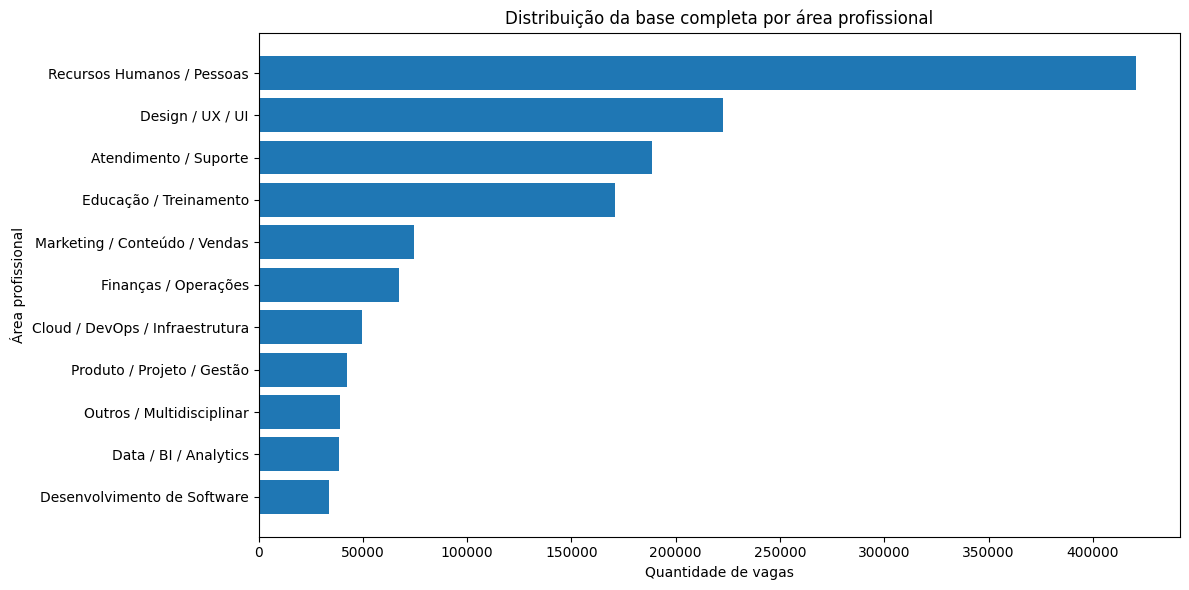

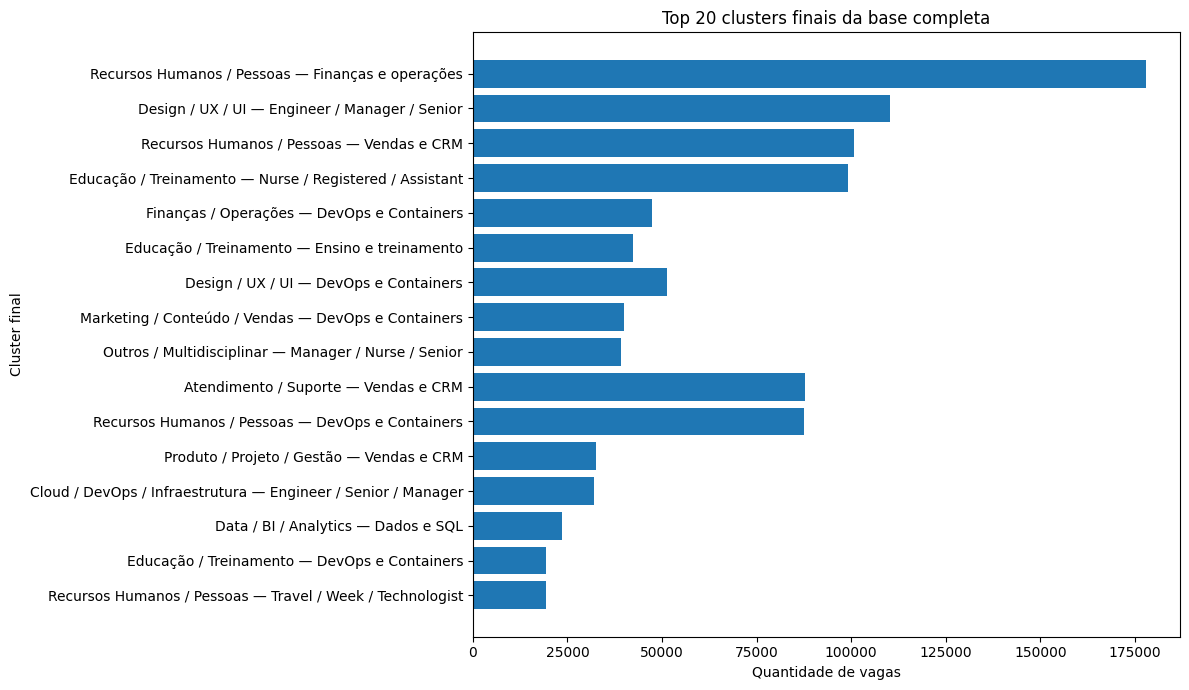

In [28]:

plt.figure(figsize=(12, 6))
df_plot = df_dist_areas_base.sort_values("qtd_vagas", ascending=True)
plt.barh(df_plot["area_profissional"].astype(str), df_plot["qtd_vagas"])
plt.title("Distribuição da base completa por área profissional")
plt.xlabel("Quantidade de vagas")
plt.ylabel("Área profissional")
plt.tight_layout()
plt.savefig(PASTA_SAIDAS / "grafico_00_distribuicao_area_base_completa.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 7))
df_top_clusters = df_diagnostico_clusters.head(20).sort_values("qtd_vagas", ascending=True)
plt.barh(df_top_clusters["nome_cluster"].astype(str), df_top_clusters["qtd_vagas"])
plt.title("Top 20 clusters finais da base completa")
plt.xlabel("Quantidade de vagas")
plt.ylabel("Cluster final")
plt.tight_layout()
plt.savefig(PASTA_SAIDAS / "grafico_00b_top_clusters_finais.png", dpi=150)
plt.show()


In [29]:
def plot_barh(series, titulo, xlabel="Quantidade", top_n=15):
    dados = series.dropna().head(top_n).sort_values()
    plt.figure(figsize=(10, 6))
    plt.barh(dados.index.astype(str), dados.values)
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.tight_layout()
    plt.show()


def salvar_fig(nome):
    plt.savefig(PASTA_SAIDAS / nome, dpi=160, bbox_inches="tight")


def plot_heatmap_tcc(matriz, titulo, xlabel="", ylabel="", figsize=(11, 6), fmt=".0f"):
    matriz = matriz.copy()
    plt.figure(figsize=figsize)
    plt.imshow(matriz.values, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(matriz.columns)), matriz.columns.astype(str), rotation=45, ha="right")
    plt.yticks(range(len(matriz.index)), matriz.index.astype(str))
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            valor = matriz.values[i, j]
            if pd.notna(valor):
                plt.text(j, i, format(valor, fmt), ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

# Garante colunas novas no pool de recomendação.
garantir_colunas_recomendador()

NameError: name 'garantir_colunas_recomendador' is not defined

## Gráfico 1 — Distribuição das postagens por área profissional prevista

In [ ]:
areas_posts = df_analise_posts["area_profissional"].value_counts()
plot_barh(areas_posts, "Postagens dos estudantes por área profissional prevista", top_n=20)

## Gráfico 2 — Score máximo por estudante e área profissional

In [ ]:
dados = df_analise_posts.sort_values("score_maximo")
labels = dados["nome"] + " | " + dados["area_profissional"].astype(str)
plt.figure(figsize=(11, 6))
plt.barh(labels, dados["score_maximo"])
plt.title("Score máximo de compatibilidade por estudante e área")
plt.xlabel("Score percentual")
plt.tight_layout()
plt.show()

## Gráfico 3 — Score médio por área profissional prevista

In [ ]:
score_area = df_analise_posts.groupby("area_profissional")["score_maximo"].mean().sort_values(ascending=False)
plot_barh(score_area, "Score médio das postagens por área profissional", xlabel="Score médio", top_n=20)

## Gráfico 4 — Distribuição por ranking de compatibilidade

In [ ]:
ordem_rank = [
    "Nada compatível", "Muito pouco compatível", "Pouco compatível",
    "Moderadamente compatível", "Compatível", "Compatível alto", "Muito compatível"
]
ranking_counts = df_analise_posts["categoria_compatibilidade"].value_counts().reindex(ordem_rank).fillna(0)
plot_barh(ranking_counts, "Distribuição das postagens por ranking de compatibilidade", top_n=7)

## Gráfico 5 — Heatmap curso x área profissional prevista

In [ ]:
matriz_curso_area = pd.crosstab(df_analise_posts["curso"], df_analise_posts["area_profissional"])
plot_heatmap_tcc(
    matriz_curso_area,
    "Heatmap: curso x área profissional prevista",
    xlabel="Área profissional",
    ylabel="Curso",
    figsize=(13, 6)
)

## Gráfico 6 — Heatmap curso x ranking de compatibilidade

In [ ]:
matriz_curso_ranking = pd.crosstab(
    df_analise_posts["curso"],
    df_analise_posts["categoria_compatibilidade"]
).reindex(columns=ordem_rank, fill_value=0)
plot_heatmap_tcc(
    matriz_curso_ranking,
    "Heatmap: curso x ranking de compatibilidade",
    xlabel="Ranking",
    ylabel="Curso",
    figsize=(13, 6)
)

## Gráfico 7 — Skills mais recomendadas no novo modelo

In [ ]:
top_skills_recomendadas = (
    df_skills_recomendadas
    .groupby("skill_recomendada")["frequencia"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)
plot_barh(top_skills_recomendadas, "Top 20 skills recomendadas para evolução dos estudantes")

## Gráfico 8 — Skills recomendadas por área profissional

In [ ]:
top_skills = df_skills_recomendadas["skill_recomendada"].value_counts().head(12).index
matriz_skill_area = pd.crosstab(
    df_skills_recomendadas[df_skills_recomendadas["skill_recomendada"].isin(top_skills)]["area_profissional"],
    df_skills_recomendadas[df_skills_recomendadas["skill_recomendada"].isin(top_skills)]["skill_recomendada"]
)
plot_heatmap_tcc(
    matriz_skill_area,
    "Heatmap: skills recomendadas x área profissional",
    xlabel="Skill recomendada",
    ylabel="Área profissional",
    figsize=(14, 7)
)

## Gráfico 9 — Áreas profissionais mais presentes no pool de vagas recomendáveis

In [ ]:
if 'df_recomendacoes' in globals() and len(df_recomendacoes) > 0 and 'area_profissional' in df_recomendacoes.columns:
    areas_vagas_recomendadas = df_recomendacoes['area_profissional'].astype(str).value_counts().head(20)
    plot_barh(areas_vagas_recomendadas, 'Áreas profissionais mais frequentes nas vagas recomendadas', top_n=20)
elif 'df_amostra' in globals() and 'area_profissional' in df_amostra.columns:
    areas_vagas_recomendadas = df_amostra['area_profissional'].astype(str).value_counts().head(20)
    plot_barh(areas_vagas_recomendadas, 'Áreas profissionais mais presentes na base completa', top_n=20)
else:
    print('Sem dados de área profissional para gerar este gráfico.')


## Gráfico 10 — Score das recomendações por área da postagem

In [ ]:
plt.figure(figsize=(11, 6))
areas = df_recomendacoes["area_profissional_postagem"].dropna().unique().tolist()
dados_box = [
    df_recomendacoes.loc[df_recomendacoes["area_profissional_postagem"] == area, "score_percentual"].dropna().values
    for area in areas
]
plt.boxplot(dados_box, labels=areas, vert=False)
plt.title("Distribuição dos scores das vagas recomendadas por área da postagem")
plt.xlabel("Score percentual")
plt.tight_layout()
plt.show()

## Gráfico 11 — Quantidade de skills recomendadas por postagem

In [ ]:
dados = df_analise_posts.sort_values("qtd_skills_recomendadas")
plt.figure(figsize=(10, 6))
plt.barh(dados["nome"] + " | " + dados["titulo_postagem"].str[:25], dados["qtd_skills_recomendadas"])
plt.title("Quantidade de skills recomendadas por postagem")
plt.xlabel("Quantidade de skills")
plt.tight_layout()
plt.show()

## Gráfico 12 — Localidades mais frequentes nas vagas recomendadas

In [ ]:
top_locais_recomendados = df_recomendacoes["job_location"].replace("", "Não informado").fillna("Não informado").value_counts().head(20)
plot_barh(top_locais_recomendados, "Top localidades dentro das vagas recomendadas", top_n=20)

## Gráfico 13 — Cargos mais recomendados aos estudantes

In [ ]:
top_cargos_recomendados = df_recomendacoes["job_title"].replace("", np.nan).dropna().value_counts().head(20)
plot_barh(top_cargos_recomendados, "Top cargos mais recomendados aos estudantes", top_n=20)

## Gráfico 14 — Score médio por curso

In [ ]:
score_curso = df_analise_posts.groupby("curso")["score_maximo"].mean().sort_values(ascending=False)
plot_barh(score_curso, "Score médio por curso", xlabel="Score médio", top_n=20)

## Gráfico 15 — Relação entre score e quantidade de skills recomendadas

In [ ]:
plt.figure(figsize=(9, 6))
plt.scatter(df_analise_posts["score_maximo"], df_analise_posts["qtd_skills_recomendadas"], s=80, alpha=0.75)
for _, row in df_analise_posts.iterrows():
    plt.text(row["score_maximo"] + 0.3, row["qtd_skills_recomendadas"] + 0.05, str(row["nome"]), fontsize=8)
plt.title("Score de compatibilidade x quantidade de skills recomendadas")
plt.xlabel("Score máximo")
plt.ylabel("Qtd. skills recomendadas")
plt.tight_layout()
plt.show()

# 20. Camada de sistema real: eventos, engajamento e indicadores

Até aqui o notebook analisa texto e compatibilidade. Para virar algo mais real dentro da UNIGRAN Social, o sistema também precisa gerar dados que um backend ou dashboard consiga consumir.

Nesta etapa criamos uma camada simulada de eventos da rede social, representando visualizações, curtidas, comentários, salvamentos e compartilhamentos das postagens. Em um sistema real, esses dados viriam do banco da aplicação.


In [ ]:
# Configuração leve para não estourar RAM no Colab.
# Se o ambiente estiver forte, aumente esses valores.
CONFIG_SISTEMA_REAL = {
    "max_pontos_temporais_por_post": 8,
    "janela_dias_simulada": 45,
    "salvar_graficos": True,
    "pasta_graficos": str(PASTA_SAIDAS / "graficos_tcc")
}

PASTA_GRAFICOS = Path(CONFIG_SISTEMA_REAL["pasta_graficos"])
PASTA_GRAFICOS.mkdir(parents=True, exist_ok=True)

print("Configuração da camada real:")
print(json.dumps(CONFIG_SISTEMA_REAL, indent=2, ensure_ascii=False))


In [ ]:
def gerar_eventos_simulados_postagens(df_analise, seed=RANDOM_STATE):
    """Cria eventos simulados usando o novo formato de área profissional.

    Em produção, esta função seria substituída por uma consulta SQL/API.
    """
    rng = np.random.default_rng(seed)
    linhas = []
    hoje = pd.Timestamp.today().normalize()

    for _, row in df_analise.iterrows():
        score = float(row.get("score_maximo", 0))
        ranking = int(row.get("ranking", 1))
        area = row.get("area_profissional", row.get("nome_cluster", "Área não identificada"))
        n_pontos = int(CONFIG_SISTEMA_REAL["max_pontos_temporais_por_post"])

        for d in range(n_pontos):
            data_evento = hoje - pd.Timedelta(days=int(rng.integers(0, CONFIG_SISTEMA_REAL["janela_dias_simulada"])))

            # Quanto maior a compatibilidade, maior tende a ser o interesse gerado.
            base_views = max(20, int(40 + score * 2.5 + ranking * 12))
            visualizacoes = int(max(1, rng.normal(base_views, base_views * 0.25)))
            curtidas = int(max(0, visualizacoes * rng.uniform(0.04, 0.18)))
            comentarios = int(max(0, visualizacoes * rng.uniform(0.005, 0.04)))
            salvamentos = int(max(0, visualizacoes * rng.uniform(0.01, 0.08)))
            compartilhamentos = int(max(0, visualizacoes * rng.uniform(0.002, 0.025)))

            linhas.append({
                "data_evento": data_evento,
                "id_usuario": row["id_usuario"],
                "nome": row["nome"],
                "curso": row["curso"],
                "semestre": row["semestre"],
                "titulo_postagem": row["titulo_postagem"],
                "area_profissional": area,
                "nome_cluster": area,
                "ranking": ranking,
                "categoria_compatibilidade": row["categoria_compatibilidade"],
                "score_maximo": score,
                "qtd_skills_recomendadas": int(row.get("qtd_skills_recomendadas", 0)),
                "visualizacoes": visualizacoes,
                "curtidas": curtidas,
                "comentarios": comentarios,
                "salvamentos": salvamentos,
                "compartilhamentos": compartilhamentos,
            })

    eventos = pd.DataFrame(linhas)
    eventos["interacoes"] = eventos[["curtidas", "comentarios", "salvamentos", "compartilhamentos"]].sum(axis=1)
    eventos["taxa_engajamento"] = np.where(
        eventos["visualizacoes"] > 0,
        eventos["interacoes"] / eventos["visualizacoes"],
        0
    )
    eventos["mes_referencia"] = eventos["data_evento"].dt.to_period("M").astype(str)
    eventos["semana_referencia"] = eventos["data_evento"].dt.to_period("W").astype(str)
    return eventos.sort_values("data_evento")


df_eventos = gerar_eventos_simulados_postagens(df_analise_posts)
df_eventos.head()

# 21. Tabelas analíticas para dashboard

Essas tabelas são o que normalmente iria para o frontend, Power BI, Metabase ou outro painel da coordenação.


In [ ]:
df_dashboard_geral = pd.DataFrame([{
    "total_postagens": int(df_analise_posts["titulo_postagem"].nunique()),
    "total_estudantes": int(df_analise_posts["id_usuario"].nunique()),
    "areas_profissionais_identificadas": int(df_analise_posts["area_profissional"].nunique()),
    "score_medio": round(float(df_analise_posts["score_maximo"].mean()), 2),
    "score_medio_top10": round(float(df_analise_posts["score_medio_top10"].mean()), 2),
    "ranking_medio": round(float(df_analise_posts["ranking"].mean()), 2),
    "skills_recomendadas_total": int(df_skills_recomendadas["skill_recomendada"].nunique()) if len(df_skills_recomendadas) else 0,
    "total_visualizacoes": int(df_eventos["visualizacoes"].sum()),
    "total_interacoes": int(df_eventos["interacoes"].sum()),
    "taxa_engajamento_media": round(float(df_eventos["taxa_engajamento"].mean()), 4),
}])


df_dashboard_curso = (
    df_analise_posts
    .groupby("curso", as_index=False)
    .agg(
        estudantes=("id_usuario", "nunique"),
        postagens=("titulo_postagem", "count"),
        areas_profissionais=("area_profissional", "nunique"),
        score_medio=("score_maximo", "mean"),
        score_medio_top10=("score_medio_top10", "mean"),
        ranking_medio=("ranking", "mean"),
        skills_recomendadas_media=("qtd_skills_recomendadas", "mean")
    )
    .sort_values("score_medio", ascending=False)
)


df_dashboard_area = (
    df_analise_posts
    .groupby("area_profissional", as_index=False)
    .agg(
        postagens=("titulo_postagem", "count"),
        cursos=("curso", "nunique"),
        score_medio=("score_maximo", "mean"),
        score_medio_top10=("score_medio_top10", "mean"),
        ranking_medio=("ranking", "mean"),
        skills_recomendadas_media=("qtd_skills_recomendadas", "mean")
    )
    .sort_values("postagens", ascending=False)
)

# Alias para manter compatibilidade com células antigas.
df_dashboard_cluster = df_dashboard_area.rename(columns={"area_profissional": "nome_cluster"}).copy()

print("Indicadores gerais")
display(df_dashboard_geral)
print("Indicadores por curso")
display(df_dashboard_curso)
print("Indicadores por área profissional")
display(df_dashboard_area)

# 22. Visualizações avançadas para TCC e dashboard

Aqui entram gráficos mais fortes para apresentação: heatmaps, matriz de compatibilidade, funil, bolhas e análise temporal.


In [ ]:
def salvar_ou_mostrar(nome_arquivo=None):
    """Salva o gráfico atual e exibe em seguida."""
    if nome_arquivo and CONFIG_SISTEMA_REAL.get("salvar_graficos", True):
        plt.savefig(PASTA_GRAFICOS / nome_arquivo, dpi=180, bbox_inches="tight")
    plt.show()


def heatmap_matriz(df_matriz, titulo, nome_arquivo=None, figsize=(10, 6), fmt=".0f"):
    matriz = df_matriz.copy()
    plt.figure(figsize=figsize)
    plt.imshow(matriz.values, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(matriz.columns)), matriz.columns.astype(str), rotation=45, ha="right")
    plt.yticks(range(len(matriz.index)), matriz.index.astype(str))
    plt.title(titulo)

    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            valor = matriz.values[i, j]
            if pd.notna(valor):
                texto = format(valor, fmt) if isinstance(valor, (int, float, np.integer, np.floating)) else str(valor)
                plt.text(j, i, texto, ha="center", va="center", fontsize=8)

    plt.tight_layout()
    salvar_ou_mostrar(nome_arquivo)


## Visual 16 — Heatmap curso x área profissional prevista

Mostra quais cursos estão mais associados a cada área profissional prevista pelo novo modelo.

In [ ]:
matriz_curso_area = pd.crosstab(df_analise_posts["curso"], df_analise_posts["area_profissional"])
heatmap_matriz(
    matriz_curso_area,
    "Heatmap: curso x área profissional prevista",
    "16_heatmap_curso_area_profissional.png",
    figsize=(13, 6),
    fmt=".0f"
)

## Visual 17 — Heatmap ranking x área profissional

Mostra em quais áreas os estudantes estão mais ou menos compatíveis.

In [ ]:
matriz_ranking_area = pd.crosstab(
    df_analise_posts["categoria_compatibilidade"],
    df_analise_posts["area_profissional"]
).reindex(index=ordem_rank, fill_value=0)
heatmap_matriz(
    matriz_ranking_area,
    "Heatmap: ranking de compatibilidade x área profissional",
    "17_heatmap_ranking_area.png",
    figsize=(13, 6),
    fmt=".0f"
)

## Visual 18 — Heatmap de skills recomendadas por curso

Ajuda a coordenação a entender quais competências precisam ser reforçadas em cada curso, usando o novo motor de recomendação.

In [ ]:
if len(df_skills_recomendadas):
    top_skills_heatmap = df_skills_recomendadas["skill_recomendada"].value_counts().head(12).index
    matriz_skill_curso = pd.crosstab(
        df_skills_recomendadas[df_skills_recomendadas["skill_recomendada"].isin(top_skills_heatmap)]["curso"],
        df_skills_recomendadas[df_skills_recomendadas["skill_recomendada"].isin(top_skills_heatmap)]["skill_recomendada"]
    )

    heatmap_matriz(
        matriz_skill_curso,
        "Heatmap: principais skills recomendadas por curso",
        "18_heatmap_skills_por_curso.png",
        figsize=(13, 6),
        fmt=".0f"
    )
else:
    print("Sem skills recomendadas para gerar o heatmap.")

## Visual 19 — Funil de maturidade profissional

Agrupa as postagens por nível de compatibilidade. Serve para mostrar quantos estudantes estão prontos, em desenvolvimento ou distantes do mercado.


In [ ]:
ordem_rankings = [
    "Muito compatível", "Compatível alto", "Compatível", "Moderadamente compatível",
    "Pouco compatível", "Muito pouco compatível", "Nada compatível"
]
funil = df_analise_posts["categoria_compatibilidade"].value_counts().reindex(ordem_rankings).dropna()

plt.figure(figsize=(10, 6))
plt.barh(funil.index[::-1], funil.values[::-1])
plt.title("Funil de maturidade profissional das postagens")
plt.xlabel("Quantidade de postagens")
plt.tight_layout()
salvar_ou_mostrar("19_funil_maturidade_profissional.png")


## Visual 20 — Bolhas: score x engajamento

Mostra se postagens mais compatíveis com o mercado também geram mais interação dentro da plataforma.


In [ ]:
df_bolhas = (
    df_eventos
    .groupby(["id_usuario", "titulo_postagem", "curso", "area_profissional"], as_index=False)
    .agg(
        score_maximo=("score_maximo", "mean"),
        qtd_skills_recomendadas=("qtd_skills_recomendadas", "mean"),
        visualizacoes=("visualizacoes", "sum"),
        interacoes=("interacoes", "sum"),
        taxa_engajamento=("taxa_engajamento", "mean")
    )
)

plt.figure(figsize=(10, 6))
tamanhos = np.clip(df_bolhas["visualizacoes"] / max(df_bolhas["visualizacoes"].max(), 1) * 900, 80, 900)
plt.scatter(df_bolhas["score_maximo"], df_bolhas["taxa_engajamento"], s=tamanhos, alpha=0.65)
for _, row in df_bolhas.iterrows():
    plt.text(row["score_maximo"] + 0.2, row["taxa_engajamento"] + 0.001, str(row["nome"]) if "nome" in row else "", fontsize=8)
plt.title("Bolhas: compatibilidade com mercado x taxa de engajamento")
plt.xlabel("Score máximo de compatibilidade")
plt.ylabel("Taxa média de engajamento")
plt.tight_layout()
salvar_ou_mostrar("20_bolhas_score_engajamento.png")

## Visual 21 — Evolução temporal de engajamento

Mostra a evolução das interações ao longo do tempo. Em produção, isso ajudaria a medir crescimento da rede social.


In [ ]:
serie_temporal = (
    df_eventos
    .groupby("data_evento", as_index=False)
    .agg(
        visualizacoes=("visualizacoes", "sum"),
        interacoes=("interacoes", "sum")
    )
    .sort_values("data_evento")
)

plt.figure(figsize=(11, 5))
plt.plot(serie_temporal["data_evento"], serie_temporal["visualizacoes"], marker="o", label="Visualizações")
plt.plot(serie_temporal["data_evento"], serie_temporal["interacoes"], marker="o", label="Interações")
plt.title("Evolução temporal de visualizações e interações")
plt.xlabel("Data")
plt.ylabel("Quantidade")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
salvar_ou_mostrar("21_evolucao_temporal_engajamento.png")


## Visual 22 — Radar comparativo por curso

Compara cursos usando score médio, ranking médio, engajamento, visualizações e recomendações de skills.


In [ ]:
df_radar = df_eventos.groupby("curso", as_index=False).agg(
    score_medio=("score_maximo", "mean"),
    ranking_medio=("ranking", "mean"),
    skills_recomendadas_media=("qtd_skills_recomendadas", "mean"),
    visualizacoes=("visualizacoes", "sum"),
    interacoes=("interacoes", "sum"),
    taxa_engajamento=("taxa_engajamento", "mean")
)

metricas_radar = ["score_medio", "ranking_medio", "skills_recomendadas_media", "visualizacoes", "interacoes", "taxa_engajamento"]
radar_norm = df_radar.copy()
for col in metricas_radar:
    minimo = radar_norm[col].min()
    maximo = radar_norm[col].max()
    radar_norm[col] = 0 if maximo == minimo else (radar_norm[col] - minimo) / (maximo - minimo)

categorias = metricas_radar
angulos = np.linspace(0, 2 * np.pi, len(categorias), endpoint=False).tolist()
angulos += angulos[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
for _, row in radar_norm.head(5).iterrows():
    valores = row[categorias].tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, linewidth=2, label=row["curso"])
    ax.fill(angulos, valores, alpha=0.08)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias)
ax.set_title("Radar comparativo por curso — novo modelo")
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.10))
plt.tight_layout()
salvar_ou_mostrar("22_radar_comparativo_curso_novo_modelo.png")

# 23. Motor de decisão para produto real

Esta camada transforma o resultado do ML em uma decisão simples para a interface do sistema.


In [ ]:
def gerar_insight_automatico(score, ranking, skills_recomendadas):
    """Gera uma interpretação textual curta para mostrar no perfil ou dashboard."""
    skills_top = [s["skill"] if isinstance(s, dict) else s[0] for s in skills_recomendadas[:3]]
    skills_txt = ", ".join(skills_top) if skills_top else "novas competências técnicas"

    if ranking >= 6:
        return f"Perfil com boa aderência ao mercado. Recomendação: fortalecer {skills_txt} para aumentar competitividade."
    if ranking >= 4:
        return f"Perfil em desenvolvimento. Recomendação: publicar mais projetos práticos e evoluir em {skills_txt}."
    return f"Perfil ainda distante das vagas analisadas. Recomendação: criar projetos guiados e iniciar estudos em {skills_txt}."


def gerar_payload_sistema(postagem):
    """Retorna um pacote pronto para backend/frontend."""
    resultado = analisar_postagem_unigran(
        id_usuario=postagem["id_usuario"],
        titulo_postagem=postagem["titulo_postagem"],
        descricao_postagem=postagem["texto_postagem"],
        tags=postagem.get("tags", ""),
        top_n=5
    )

    resultado["insight_automatico"] = gerar_insight_automatico(
        resultado["score_maximo"],
        resultado["ranking"],
        resultado["skills_recomendadas"]
    )
    resultado["status_produto"] = "ok"
    resultado["versao_modelo"] = "unigran-social-ml-v2"
    resultado["gerado_em"] = datetime.now().isoformat()
    return resultado

payload_exemplo_sistema = gerar_payload_sistema(df_posts.iloc[0].to_dict())
print(json.dumps(payload_exemplo_sistema, ensure_ascii=False, indent=2)[:2500])


# 24. Exportação para backend, dashboard e TCC

Além dos CSVs, o notebook agora gera JSONs que podem ser consumidos diretamente por uma API, frontend ou painel.


In [ ]:
# Exportações adicionais da camada real
df_eventos.to_csv(PASTA_SAIDAS / "eventos_rede_social_simulados.csv", index=False)
df_dashboard_geral.to_csv(PASTA_SAIDAS / "dashboard_geral.csv", index=False)
df_dashboard_curso.to_csv(PASTA_SAIDAS / "dashboard_por_curso.csv", index=False)
df_dashboard_area.to_csv(PASTA_SAIDAS / "dashboard_por_area_profissional.csv", index=False)
df_dashboard_cluster.to_csv(PASTA_SAIDAS / "dashboard_por_cluster.csv", index=False)

payload_dashboard = {
    "geral": df_dashboard_geral.to_dict(orient="records"),
    "por_curso": df_dashboard_curso.round(4).to_dict(orient="records"),
    "por_area_profissional": df_dashboard_area.round(4).to_dict(orient="records"),
    "ranking_compatibilidade": df_analise_posts[[
        "id_usuario", "nome", "curso", "semestre", "titulo_postagem", "area_profissional",
        "score_maximo", "score_medio_top10", "ranking", "categoria_compatibilidade",
        "skills_recomendadas"
    ]].to_dict(orient="records"),
    "skills_recomendadas": df_skills_recomendadas.to_dict(orient="records"),
    "eventos_resumo": df_eventos.groupby("data_evento", as_index=False)[["visualizacoes", "interacoes"]].sum().assign(
        data_evento=lambda x: x["data_evento"].astype(str)
    ).to_dict(orient="records")
}

with open(PASTA_SAIDAS / "payload_dashboard_unigran_social_novo_formato.json", "w", encoding="utf-8") as f:
    json.dump(payload_dashboard, f, ensure_ascii=False, indent=2)

# Mantém nome antigo também.
with open(PASTA_SAIDAS / "payload_dashboard_unigran_social.json", "w", encoding="utf-8") as f:
    json.dump(payload_dashboard, f, ensure_ascii=False, indent=2)

print("Exportações adicionais geradas em:", PASTA_SAIDAS.resolve())
print("Gráficos salvos em:", PASTA_GRAFICOS.resolve())

# 20. Explicabilidade simples: termos que influenciam cada cluster

Esta tabela ajuda a explicar para a banca o que cada cluster representa.

In [ ]:
linhas = []
for cluster, termos in termos_clusters.items():
    linhas.append({
        "cluster": cluster,
        "nome_cluster": nomes_clusters.get(cluster, "Perfil profissional misto"),
        "termos_relevantes": ", ".join(termos)
    })

df_explicacao_clusters = pd.DataFrame(linhas).sort_values("cluster")
df_explicacao_clusters.to_csv(PASTA_SAIDAS / "explicacao_clusters.csv", index=False)
df_explicacao_clusters

# 21. Função final para integração com a rede social

Essa função é a que o backend deve chamar futuramente.

In [ ]:
def analisar_postagem_unigran(id_usuario, titulo_postagem, descricao_postagem, tags="", top_n=5):
    texto = f"{titulo_postagem} {descricao_postagem} {tags}"
    resultado = recomendar_para_postagem(texto, top_n=top_n)
    recs = resultado["recomendacoes"]

    score_max = float(recs["score_percentual"].max()) if len(recs) else 0
    ranking, categoria = categorizar_compatibilidade(score_max)

    return {
        "id_usuario": id_usuario,
        "titulo_postagem": titulo_postagem,
        "cluster_previsto": resultado["cluster_previsto"],
        "area_profissional_aproximada": resultado["nome_cluster"],
        "score_maximo": round(score_max, 2),
        "ranking": ranking,
        "categoria_compatibilidade": categoria,
        "skills_recomendadas": [
            {"skill": skill, "frequencia": int(freq)}
            for skill, freq in resultado["skills_recomendadas"][:10]
        ],
        "vagas_compativeis": recs.head(top_n).to_dict(orient="records")
    }

saida_teste = analisar_postagem_unigran(
    id_usuario=101,
    titulo_postagem="Sistema de recomendação com machine learning",
    descricao_postagem="Desenvolvi um modelo em Python usando pandas, scikit-learn, TF-IDF e similaridade de cosseno para recomendar conteúdos.",
    tags="Python, Machine Learning, TF-IDF, Recomendação, Data Science",
    top_n=5
)

saida_teste

# 22. Persistência dos artefatos do modelo

Esta versão salva somente artefatos leves e úteis.

O notebook **não salva a matriz vetorial da base inteira**, porque isso pode estourar RAM e disco no Kaggle.

São salvos:

- vetorizador e configurações;
- modelos de subcluster por área;
- nomes dos clusters;
- taxonomia profissional;
- análises dos estudantes;
- diagnóstico dos clusters;
- base de vagas processada em CSV leve;
- arquivo `.zip` com `models` e `outputs` para baixar no Kaggle.


# Opção de escala real: pipeline incremental

Use esta seção quando quiser sair da fase de demonstração e processar centenas de milhares ou mais de 1 milhão de registros.

A ideia é trocar `TfidfVectorizer` por `HashingVectorizer`, porque ele não guarda vocabulário em RAM, e treinar o `MiniBatchKMeans` com `partial_fit()` em blocos.

Esta seção está como referência técnica para produção. Para o TCC, o pipeline principal acima já é suficiente e mais interpretável.


In [ ]:
# EXEMPLO OPCIONAL — não precisa rodar para a apresentação do TCC.
# Use quando quiser treinar em escala usando chunks direto do CSV, sem carregar tudo de uma vez.

def treinar_cluster_incremental_csv(csv_path, colunas_texto=None, chunksize=10000, n_clusters=12):
    if colunas_texto is None:
        colunas_texto = ["job_title", "job_skills", "job_summary"]

    vectorizer_hash = HashingVectorizer(
        n_features=HASHING_N_FEATURES,
        ngram_range=(1, 2),
        norm="l2",
        alternate_sign=False,
        preprocessor=limpar_texto,
        lowercase=False,
        dtype=np.float32
    )

    modelo_incremental = MiniBatchKMeans(
        n_clusters=n_clusters,
        batch_size=KMEANS_BATCH_SIZE,
        random_state=RANDOM_STATE,
        n_init=10
    )

    total = 0

    for chunk in pd.read_csv(csv_path, chunksize=chunksize, dtype=str, low_memory=False):
        colunas_existentes = [c for c in colunas_texto if c in chunk.columns]
        if not colunas_existentes:
            raise ValueError(f"Nenhuma das colunas {colunas_texto} foi encontrada no CSV.")

        def iter_chunk_textos():
            for _, row in chunk[colunas_existentes].fillna("").iterrows():
                yield " ".join(str(v) for v in row.values)

        X_chunk = vectorizer_hash.transform(iter_chunk_textos())
        modelo_incremental.partial_fit(X_chunk)

        total += len(chunk)
        print(f"Processadas {total:,} linhas")

        del chunk, X_chunk
        gc.collect()

    return vectorizer_hash, modelo_incremental


In [ ]:
# Persistência dos artefatos profundos.
# Não salvamos matriz da base inteira. Isso é intencional para não quebrar RAM/disco.

modelo_config = {
    "random_state": RANDOM_STATE,
    "hashing_n_features": HASHING_N_FEATURES,
    "hashing_ngram_range": HASHING_NGRAM_RANGE,
    "hashing_alternate_sign": HASHING_ALTERNATE_SIGN,
    "chunk_vetorizacao": CHUNK_VETORIZACAO,
    "subclusters_min_registros": SUBCLUSTERS_MIN_REGISTROS,
    "subclusters_max_por_area": SUBCLUSTERS_MAX_POR_AREA,
    "top_n_recomendacoes": TOP_N_RECOMENDACOES,
    "top_n_candidatos_chunk": TOP_N_CANDIDATOS_CHUNK,
}

joblib.dump(modelos_subcluster, PASTA_MODELOS / "modelos_subcluster_por_area.pkl", compress=3)
joblib.dump(nomes_clusters, PASTA_MODELOS / "nomes_clusters.pkl", compress=3)
joblib.dump(AREA_TAXONOMIA, PASTA_MODELOS / "area_taxonomia.pkl", compress=3)
joblib.dump(modelo_config, PASTA_MODELOS / "modelo_config.pkl", compress=3)

# O HashingVectorizer é determinístico. Salvamos também o objeto, mas a API pode recriá-lo pela config.
joblib.dump(vectorizer, PASTA_MODELOS / "hashing_vectorizer.pkl", compress=3)

# Base completa leve: mantém apenas colunas necessárias para análise/recomendação.
colunas_base_leve = [
    "job_title", "company", "job_location", "job_skills", "job_link", "job_summary",
    "area_profissional", "area_id", "score_area", "subcluster", "cluster", "nome_cluster",
    "qtd_palavras", "qtd_skills", "tamanho_resumo", "tem_skills"
]
colunas_base_leve = [c for c in colunas_base_leve if c in df_amostra.columns]

# CSV é mais seguro no Kaggle do que pickle gigante.
df_amostra[colunas_base_leve].to_csv(PASTA_MODELOS / "base_vagas_processada_leve.csv", index=False)

# Tabelas principais do modelo profundo.
df_analise_posts.to_csv(PASTA_MODELOS / "analise_posts_estudantes_profunda.csv", index=False)
df_recomendacoes.to_csv(PASTA_MODELOS / "recomendacoes_vagas_profunda.csv", index=False)
df_skills_recomendadas.to_csv(PASTA_MODELOS / "skills_recomendadas_profunda.csv", index=False)
df_diagnostico_clusters.to_csv(PASTA_MODELOS / "diagnostico_clusters_base_completa.csv", index=False)
df_dist_areas_base.to_csv(PASTA_MODELOS / "distribuicao_areas_base_completa.csv", index=False)
metricas_clusters.to_csv(PASTA_MODELOS / "planejamento_subclusters_por_area.csv", index=False)

print("Artefatos profundos salvos em:", PASTA_MODELOS.resolve())
print("Arquivos em models:")
for nome in sorted(os.listdir(PASTA_MODELOS)):
    caminho = PASTA_MODELOS / nome
    tamanho_mb = caminho.stat().st_size / (1024 * 1024)
    print(f"- {nome} | {tamanho_mb:.2f} MB")


# Como pegar os arquivos no Kaggle

No Kaggle, tudo que o notebook gera fica em:

```text
/kaggle/working/
```

Neste notebook, os arquivos principais ficam em:

```text
/kaggle/working/models
/kaggle/working/outputs
/kaggle/working/graficos
```

Ao final da execução, a próxima célula cria arquivos `.zip` para facilitar o download.


In [ ]:
import shutil

# Cria ZIPs para baixar pelo painel Output do Kaggle.
zip_models = shutil.make_archive("/kaggle/working/models_unigran_social_ml", "zip", str(PASTA_MODELOS))
zip_outputs = shutil.make_archive("/kaggle/working/outputs_unigran_social_ml", "zip", str(PASTA_SAIDAS))

if 'PASTA_GRAFICOS' in globals() and PASTA_GRAFICOS.exists():
    zip_graficos = shutil.make_archive("/kaggle/working/graficos_unigran_social_ml", "zip", str(PASTA_GRAFICOS))
else:
    zip_graficos = None

print("ZIP de modelos:", zip_models)
print("ZIP de outputs:", zip_outputs)
if zip_graficos:
    print("ZIP de gráficos:", zip_graficos)

print("\nPara baixar no Kaggle:")
print("1. Abra o painel lateral direito")
print("2. Vá em Output")
print("3. Procure os arquivos .zip")
print("4. Clique nos três pontinhos e depois em Download")


# 23. Modelo de API FastAPI — compatível com o modelo profundo

Este exemplo de API usa os arquivos leves salvos em `models/`.

Ele recria o `HashingVectorizer` pela configuração e varre a base processada em chunks. Isso evita carregar uma matriz gigante em memória.


In [ ]:
%%writefile api_app_exemplo.py
from fastapi import FastAPI
from pydantic import BaseModel, Field
from typing import List, Optional
from pathlib import Path
from collections import Counter
import re
import joblib
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.metrics.pairwise import cosine_similarity

PASTA_MODELOS = Path("models")
BASE_VAGAS_CSV = PASTA_MODELOS / "base_vagas_processada_leve.csv"

AREA_TAXONOMIA = joblib.load(PASTA_MODELOS / "area_taxonomia.pkl")
NOMES_CLUSTERS = joblib.load(PASTA_MODELOS / "nomes_clusters.pkl")
CONFIG = joblib.load(PASTA_MODELOS / "modelo_config.pkl")

AREAS_VALIDAS = list(AREA_TAXONOMIA.keys())
AREA_ID = {nome: i for i, nome in enumerate(AREAS_VALIDAS)}
ID_AREA = {i: nome for nome, i in AREA_ID.items()}

app = FastAPI(
    title="UNIGRAN Social ML API",
    description="API de recomendação acadêmica com macroárea, subcluster e similaridade em chunks.",
    version="4.0.0"
)

class PostagemEntrada(BaseModel):
    id_usuario: int
    titulo_postagem: str = Field(..., min_length=3)
    descricao_postagem: str = Field(..., min_length=10)
    tags: str = ""
    curso: Optional[str] = None
    semestre: Optional[int] = None
    top_n: int = Field(default=5, ge=1, le=20)

class LotePostagens(BaseModel):
    postagens: List[PostagemEntrada]


def limpar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)
    texto = re.sub(r"[^a-zA-ZÀ-ÿ0-9+#. ]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def pontuar_area_texto(texto):
    texto_limpo = limpar_texto(texto)
    melhor_area = "Outros / Multidisciplinar"
    melhor_score = 0
    for area, config in AREA_TAXONOMIA.items():
        score = 0
        for termo, peso in config.get("peso", {}).items():
            if termo in texto_limpo:
                score += int(peso)
        if score > melhor_score:
            melhor_area = area
            melhor_score = score
    return melhor_area, melhor_score


def inferir_area_texto(texto):
    return pontuar_area_texto(texto)[0]


def enriquecer_texto_por_area(texto, area):
    extra = AREA_TAXONOMIA.get(area, {}).get("expansao", "")
    return f"{texto} {extra}"


def montar_texto_linha(row, area=None):
    partes = [
        row.get("job_title", ""),
        row.get("job_skills", ""),
        row.get("job_summary", ""),
        row.get("area_profissional", "")
    ]
    texto = " ".join([str(p) for p in partes if pd.notna(p)])
    area_final = area or str(row.get("area_profissional", "Outros / Multidisciplinar"))
    return enriquecer_texto_por_area(texto, area_final)


vectorizer = HashingVectorizer(
    n_features=int(CONFIG.get("hashing_n_features", 2**16)),
    ngram_range=tuple(CONFIG.get("hashing_ngram_range", (1, 2))),
    alternate_sign=bool(CONFIG.get("hashing_alternate_sign", False)),
    norm="l2",
    lowercase=False,
    preprocessor=limpar_texto,
    dtype=np.float32
)


def categorizar_compatibilidade(score_percentual):
    if score_percentual >= 85:
        return 7, "Muito compatível"
    if score_percentual >= 70:
        return 6, "Compatível alto"
    if score_percentual >= 55:
        return 5, "Compatível"
    if score_percentual >= 40:
        return 4, "Moderadamente compatível"
    if score_percentual >= 25:
        return 3, "Pouco compatível"
    if score_percentual >= 10:
        return 2, "Muito pouco compatível"
    return 1, "Nada compatível"


def extrair_lista_skills(texto):
    partes = re.split(r"[,;|/]", str(texto))
    return [p.strip() for p in partes if len(p.strip()) > 1]


def top_indices(scores, top_k):
    if len(scores) <= top_k:
        return np.argsort(scores)[::-1]
    idx = np.argpartition(scores, -top_k)[-top_k:]
    return idx[np.argsort(scores[idx])[::-1]]


def recomendar(texto, top_n=5):
    area_prevista = inferir_area_texto(texto)
    vetor_post = vectorizer.transform([enriquecer_texto_por_area(texto, area_prevista)])
    melhores = []
    chunksize = int(CONFIG.get("chunk_vetorizacao", 10000))

    for chunk in pd.read_csv(BASE_VAGAS_CSV, chunksize=chunksize):
        if area_prevista != "Outros / Multidisciplinar" and "area_profissional" in chunk.columns:
            chunk = chunk[chunk["area_profissional"].astype(str) == area_prevista]
            if len(chunk) == 0:
                continue

        textos = [montar_texto_linha(row, area_prevista) for _, row in chunk.iterrows()]
        X = vectorizer.transform(textos)
        sims = cosine_similarity(vetor_post, X).ravel()
        idxs = top_indices(sims, min(max(top_n * 10, 30), len(sims)))

        for pos in idxs:
            row = chunk.iloc[int(pos)].to_dict()
            melhores.append((float(sims[int(pos)]), row))

        melhores = sorted(melhores, key=lambda x: x[0], reverse=True)[:top_n * 20]

    melhores = sorted(melhores, key=lambda x: x[0], reverse=True)[:top_n]
    vagas = []
    todas_skills = []

    for score_sim, vaga in melhores:
        score = round(score_sim * 100, 2)
        ranking, categoria = categorizar_compatibilidade(score)
        skills = str(vaga.get("job_skills", ""))
        todas_skills.extend(extrair_lista_skills(skills))
        vagas.append({
            "job_title": str(vaga.get("job_title", "")),
            "company": str(vaga.get("company", "")),
            "job_location": str(vaga.get("job_location", "")),
            "job_link": str(vaga.get("job_link", "")),
            "area_profissional": str(vaga.get("area_profissional", "")),
            "cluster": int(vaga.get("cluster", -1)) if str(vaga.get("cluster", "")).isdigit() else -1,
            "nome_cluster": str(vaga.get("nome_cluster", "")),
            "score_percentual": score,
            "ranking": ranking,
            "categoria_compatibilidade": categoria,
        })

    texto_limpo = limpar_texto(texto)
    contador = Counter([s for s in todas_skills if limpar_texto(s) not in texto_limpo])

    return {
        "area_profissional_prevista": area_prevista,
        "cluster_previsto": int(AREA_ID.get(area_prevista, 0) * 10),
        "nome_cluster": area_prevista,
        "vagas_recomendadas": vagas,
        "skills_recomendadas": [{"skill": s, "frequencia": int(f)} for s, f in contador.most_common(10)]
    }

@app.get("/")
def home():
    return {"status": "ok", "modelo": "UNIGRAN Social ML API V4 - clusters profundos"}

@app.post("/analisar")
def analisar_postagem(data: PostagemEntrada):
    texto = f"{data.titulo_postagem} {data.descricao_postagem} {data.tags}"
    return {"id_usuario": data.id_usuario, **recomendar(texto, top_n=data.top_n)}

@app.post("/analisar-lote")
def analisar_lote(data: LotePostagens):
    return [analisar_postagem(p) for p in data.postagens]


# 24. Exemplo de JSON para testar a API

In [ ]:
exemplo_json_api = {
    "id_usuario": 101,
    "titulo_postagem": "Dashboard financeiro em Power BI",
    "descricao_postagem": "Criei um painel com indicadores financeiros, metas, receita, custo, lucro e filtros por período.",
    "tags": "Power BI, Excel, Dashboard, Financeiro, Indicadores",
    "top_n": 5
}

print(json.dumps(exemplo_json_api, ensure_ascii=False, indent=2))

# 25. Relatório textual para usar no TCC

In [ ]:
relatorio_tcc = """
RELATÓRIO DO PIPELINE DE MACHINE LEARNING - UNIGRAN SOCIAL

1. Objetivo
Analisar postagens acadêmicas de estudantes e estimar compatibilidade com áreas, subáreas, vagas reais e skills de mercado.

2. Volume processado
- Vagas usadas na modelagem: {vagas}
- Postagens acadêmicas analisadas: {posts}
- Áreas profissionais: {areas}
- Total de clusters finais planejados: {clusters}

3. Arquitetura aplicada
- Limpeza textual em fluxo, sem criar coluna texto_limpo gigante
- Engenharia de features leve
- Taxonomia profissional PT/EN para resolver diferença entre posts em português e vagas em inglês
- HashingVectorizer para vetorização escalável
- MiniBatchKMeans por macroárea profissional
- Subclusters por área para evitar cluster único genérico
- Recomendação por similaridade direta em chunks contra a base completa
- Ranking de compatibilidade em 7 níveis
- Recomendação de skills
- Geração de indicadores para dashboard

4. Por que os clusters ficaram melhores
O modelo não tenta mais separar todo o mercado em um único KMeans. Primeiro ele entende a macroárea profissional e depois separa subtemas dentro daquela área. Isso reduz mistura de assuntos e evita que posts diferentes caiam todos no mesmo cluster.

5. Aplicação prática
Os resultados podem alimentar:
- perfil do estudante;
- dashboard do professor;
- painel da coordenação;
- ranking de competências por curso;
- recomendação de trilhas de estudo;
- recomendação de vagas e áreas profissionais.

6. Escalabilidade aplicada
- Ambiente recomendado: Kaggle Notebooks
- Base completa: sim
- Amostragem do treino principal: não
- Limite de leitura CSV: nenhum
- Vetorização: HashingVectorizer com {hashing_features} dimensões
- Redução SVD no treino principal: não utilizada
- Matriz vetorial completa da base: não é criada
- Busca de recomendações: varredura em chunks com similaridade de cosseno
- Persistência: CSV leve, PKL dos artefatos e ZIPs de download
""".format(
    vagas=len(df_amostra),
    posts=len(df_posts),
    areas=df_amostra["area_profissional"].nunique() if "area_profissional" in df_amostra.columns else 0,
    clusters=melhor_k,
    hashing_features=HASHING_N_FEATURES
)

print(relatorio_tcc)
with open(PASTA_SAIDAS / "relatorio_tcc_ml.txt", "w", encoding="utf-8") as f:
    f.write(relatorio_tcc)


# 26. Conclusão técnica

Este pipeline entrega uma solução completa de análise de dados e Machine Learning para o TCC.

Ele não depende de uma variável alvo artificial. Em vez disso, usa aprendizado não supervisionado, clusterização e recomendação por similaridade, que combinam melhor com o problema real da rede social acadêmica.

## O que o sistema entrega de informação

Para cada postagem do estudante, o ML retorna:

- área profissional aproximada;
- cluster de mercado;
- score percentual de compatibilidade;
- ranking de compatibilidade de 1 a 7;
- vagas mais parecidas;
- skills que o aluno já demonstra;
- skills que deveria desenvolver;
- dados agregados para dashboard acadêmico;
- CSVs e artefatos para API.

## Como conectar com a rede social

A rede social precisa enviar ao ML apenas:

```json
{
  "id_usuario": 101,
  "titulo_postagem": "Título do trabalho",
  "descricao_postagem": "Descrição do que foi produzido",
  "tags": "Java, MySQL, CRUD"
}
```

O ML devolve a análise pronta para exibir no perfil do estudante, painel do professor ou dashboard da coordenação.